# Modeling: peat condition -> fire

End-to-end scaffold for the modeling phase (see `modeling_notebook_explained.md`
for the full walkthrough, math, and design decisions). Flow:

1. Load the peat frame (80% histosol), restoration sites (treatment), covariates.
2. **Build the treated/control pixel-year panel** -- calendar-year dimension,
   per-year `treated`, and `years_after_treatment` event time.
   - **2b.** Attach the fire response (`attach_fire_response`), thread the
     restoration year into the Callaway-Sant'Anna cohort (`did.prepare_panel`),
     and fit the staggered difference-in-differences (`did.fit_att`) with site-clustered standard errors.
   - **2c.** Faithful Castro (2026) matching: per-year prognostic + per-vintage
     propensity scores, an event-time trajectory match, then match-first DiD.
3. `build_frame` -> tidy pixel-year table with a swappable fire response
   (the **levels / odds-ratio** route; consumes matched `units` from Stage 5-7).
4. `fit_logit_clustered` -> `odds_ratios`.

Matching adjusts on every **continuous** covariate on disk: elevation, histosol %,
the GHCN **climate normals** (precip/tmax, interpolated onto the grid in step 1b),
and the **SSURGO soil** layers. Categorical layers (drainage class, land cover) are
exact-match keys. Diagnostic plots at each step let you inspect the data as it flows.


In [1]:
# standard library
from pathlib import Path

# third-party
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

# local (peatfire)
from peatfire import (
    data_path,
    build_common_grid,
    to_common_grid,
    rasterize_polygons_to_grid,
    load_standardized,
    set_fire_style,
)
from peatfire.modeling import (
    load_completed_restoration_sites_in_analysis_crs,
    available_covariates,
    available_temporal_covariates,
    list_covariates,
    covariate_on_grid,
    attach_fire_response,
    build_frame,
    build_mask_frame,
    fit_logit_clustered,
    odds_ratios,
    pixelate,
    climate,
    build_soil_rasters,
    build_soil_database_rasters,
    inspect_soil_columns,
    # faithful-Castro (2c) score series + event-time match
    add_prognostic_score_series,
    add_propensity_score_series,
    match_controls_event_time,
    restrict_panel_to_matched,
    # diagnostics
    plot_annual_burned_area_vs_covariate,
    plot_burned_area_and_covariate_by_year,
    plot_burned_area_covariate_heatmap,
    plot_burned_area_vs_covariate,
    plot_burned_area_vs_covariates_over_years,
    plot_covariate_maps,
    plot_covariate_space,
    plot_covariate_pairs,
    plot_event_study,
    plot_matched_pairs_covariate,
    plot_candidate_control_pixels,
    plot_matched_pairs_geographic,
    plot_prognostic_trajectory,
    plot_raw_burn_rate_by_year,
    plot_raw_burn_rate_by_event_time,
    plot_score_map,
    plot_score_overlap,
    plot_temporal_covariate_by_year,
    plot_burn_rate_by_site
)
from peatfire.modeling import did
from peatfire.modeling.matching import (
    get_treated_and_control_pixels,
    attach_covariates,
    match_controls,
    balance_table,
    plot_balance,
    assemble_units,
    check_matches,
    check_balance,
)

set_fire_style()

# Every figure in this notebook is written here.
FIG_DIR = Path(data_path()).parents[0] / "outputs" / "figures" / "modeling"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("covariates on disk:", available_covariates())
print("figures ->", FIG_DIR)

covariates on disk: ['elevation', 'histosol_pct', 'precip_normal', 'tmax_normal', 'tmin_normal', 'gdd_normal', 'soil_organic_matter', 'soil_awc', 'soil_drainage_class', 'soil_site_index', 'soil_water_table_depth', 'land_cover', 'drainage']
figures -> /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/outputs/figures/modeling


/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:371: UserWarning: management: directory /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/processed/management/seus_forest_mgmt does not exist -- skipping.
  return [name for name, spec in COVARIATES.items() if _covariate_file(spec)]


## 1. Load treatment + peat frame

In [2]:
# Restoration polygons = the TREATMENT (reprojected to EPSG:5070; metres).
restoration_yr_col = 'End_Yr'
peat_restoration = load_completed_restoration_sites_in_analysis_crs(restoration_yr_col=restoration_yr_col) # drops rows with 0 for the restoration_yr_col and reprojects to EPSG:5070

In [3]:
# 80% peat extent as the sample frame.
aoi_nc_peat_80_histosol = gpd.read_file(data_path("processed", "peat_extent", "nc_peatlands_80_histosol_aoi.gpkg"))

## 1b. Climate covariates from GHCN stations, then map every layer

The climate source (`src/get_climate&soil_data.R`) gives GHCN **station points**,
not a raster. Two products come off the same station records:

- `climate.build_climate_normals` collapses each station's daily record to a
  long-run **normal** (annual precip total / mean tmax-tmin over the baseline) and
  IDW-interpolates it onto the grid; `write_climate_normals` saves them under
  `data/processed/climate/` as the **static** covariates `precip_normal`,
  `tmax_normal`, `tmin_normal`. A normal is the right thing to **match** on --
  climate is a stable site characteristic.
- `climate.build_climate_normals` with `climate.DEFAULT_GDD_ELEMENTS` builds a
  **growing-degree-days normal** (`gdd_normal`) the same way, but off Cat's monthly
  export `clim_monthly.gpkg` (`src/get_climate&soil_data_updated.R`), which already
  carries a per-station-year `totalGDD` (base 5 C growing-season warmth). Another
  static site characteristic, so it too enters the geographic **match**.
- `climate.build_annual_climate` with `climate.DEFAULT_ANNUAL_GDD_ELEMENTS` builds
  the **per-year** counterpart off the same `totalGDD` column, keeping each calendar
  year separate instead of averaging across them (`gdd_<year>_nc.tif` -> the
  temporal covariate `gdd`). So GDD, like precip and tmax, exists as a
  static/temporal *pair*: `gdd_normal` is the stable site warmth the **match** keys
  off, `gdd` is the individual year's warmth the **outcome** stage uses
  (`treated:gdd`, the warmth analogue of `treated:pdsi`). Per-year GDD is the
  noisier of the two -- `totalGDD` accumulates over whatever days a station
  reported, so a gappy station-year under-counts and there is no across-years
  average left to damp it.
- `climate.build_annual_climate` interpolates each **single year's** value onto
  the grid; `write_annual_climate` saves them under
  `data/processed/climate/annual/` (`precip_<year>_nc.tif` ...) as the
  **temporal** covariates `precip`, `tmax`, `tmin`. This year-specific weather
  belongs in the DiD / outcome stage (a `treated:precip` dry-year interaction) and
  is joined per `(x, y, year)` by `build_frame` / `attach_covariates`.
- `climate.build_annual_climate` with `climate.DEFAULT_PDSI_ELEMENTS` builds the
  per-year **scPDSI** drought index off its own long table (`nc_pdsi_long.Rds`),
  saved under `data/processed/climate/annual/` (`pdsi_<year>_nc.tif`) as the
  temporal covariate `pdsi`. scPDSI is self-calibrating (~0 = normal, negative =
  drought), so it has *no* static-normal counterpart -- it enters the DiD stage as
  a `treated:pdsi` drought-year interaction, alongside `treated:precip`.

The **soil** layers follow the same static-covariate pattern. `build_soil_rasters`
rasterises organic matter / AWC / drainage class from the raw SSURGO
`nc_soil_ssurgo.gpkg`; `build_soil_database_rasters` then augments them with
`soil_site_index` + `soil_water_table_depth` from Cat's aggregated
`soil_database.gpkg` (`src/get_climate&soil_data_updated.R`).

Then `plot_covariate_maps` draws every static covariate over the peat AOI. A
visually **flat** panel (histosol %, pinned ~90 across the 80% frame) is a
covariate with no spatial signal to match on -- the reason the elevation-only
match was degenerate, and the motivation for adding climate + soil.

outcome: MCD64A1 | years: 2001--2026 | grid: 500 m
wrote climate normals: {'precip_normal': 'precip_normal_nc.tif', 'tmax_normal': 'tmax_normal_nc.tif', 'tmin_normal': 'tmin_normal_nc.tif'}
wrote 78 per-year climate rasters: ['precip', 'tmax', 'tmin'] x [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
wrote GDD normal: {'gdd_normal': 'gdd_normal_nc.tif'}
wrote 26 per-year GDD rasters: [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
wrote 26 per-year scPDSI rasters: [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
nc_soil_ssurgo.gpkg: 341,835 polygons, 4 polygon columns
    column   dtype  n_unique  n_null                           sample
AREASYMBOL     str        40 

/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:371: UserWarning: management: directory /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/processed/management/seus_forest_mgmt does not exist -- skipping.
  return [name for name, spec in COVARIATES.items() if _covariate_file(spec)]


saved /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/outputs/figures/modeling/covariate_maps.png


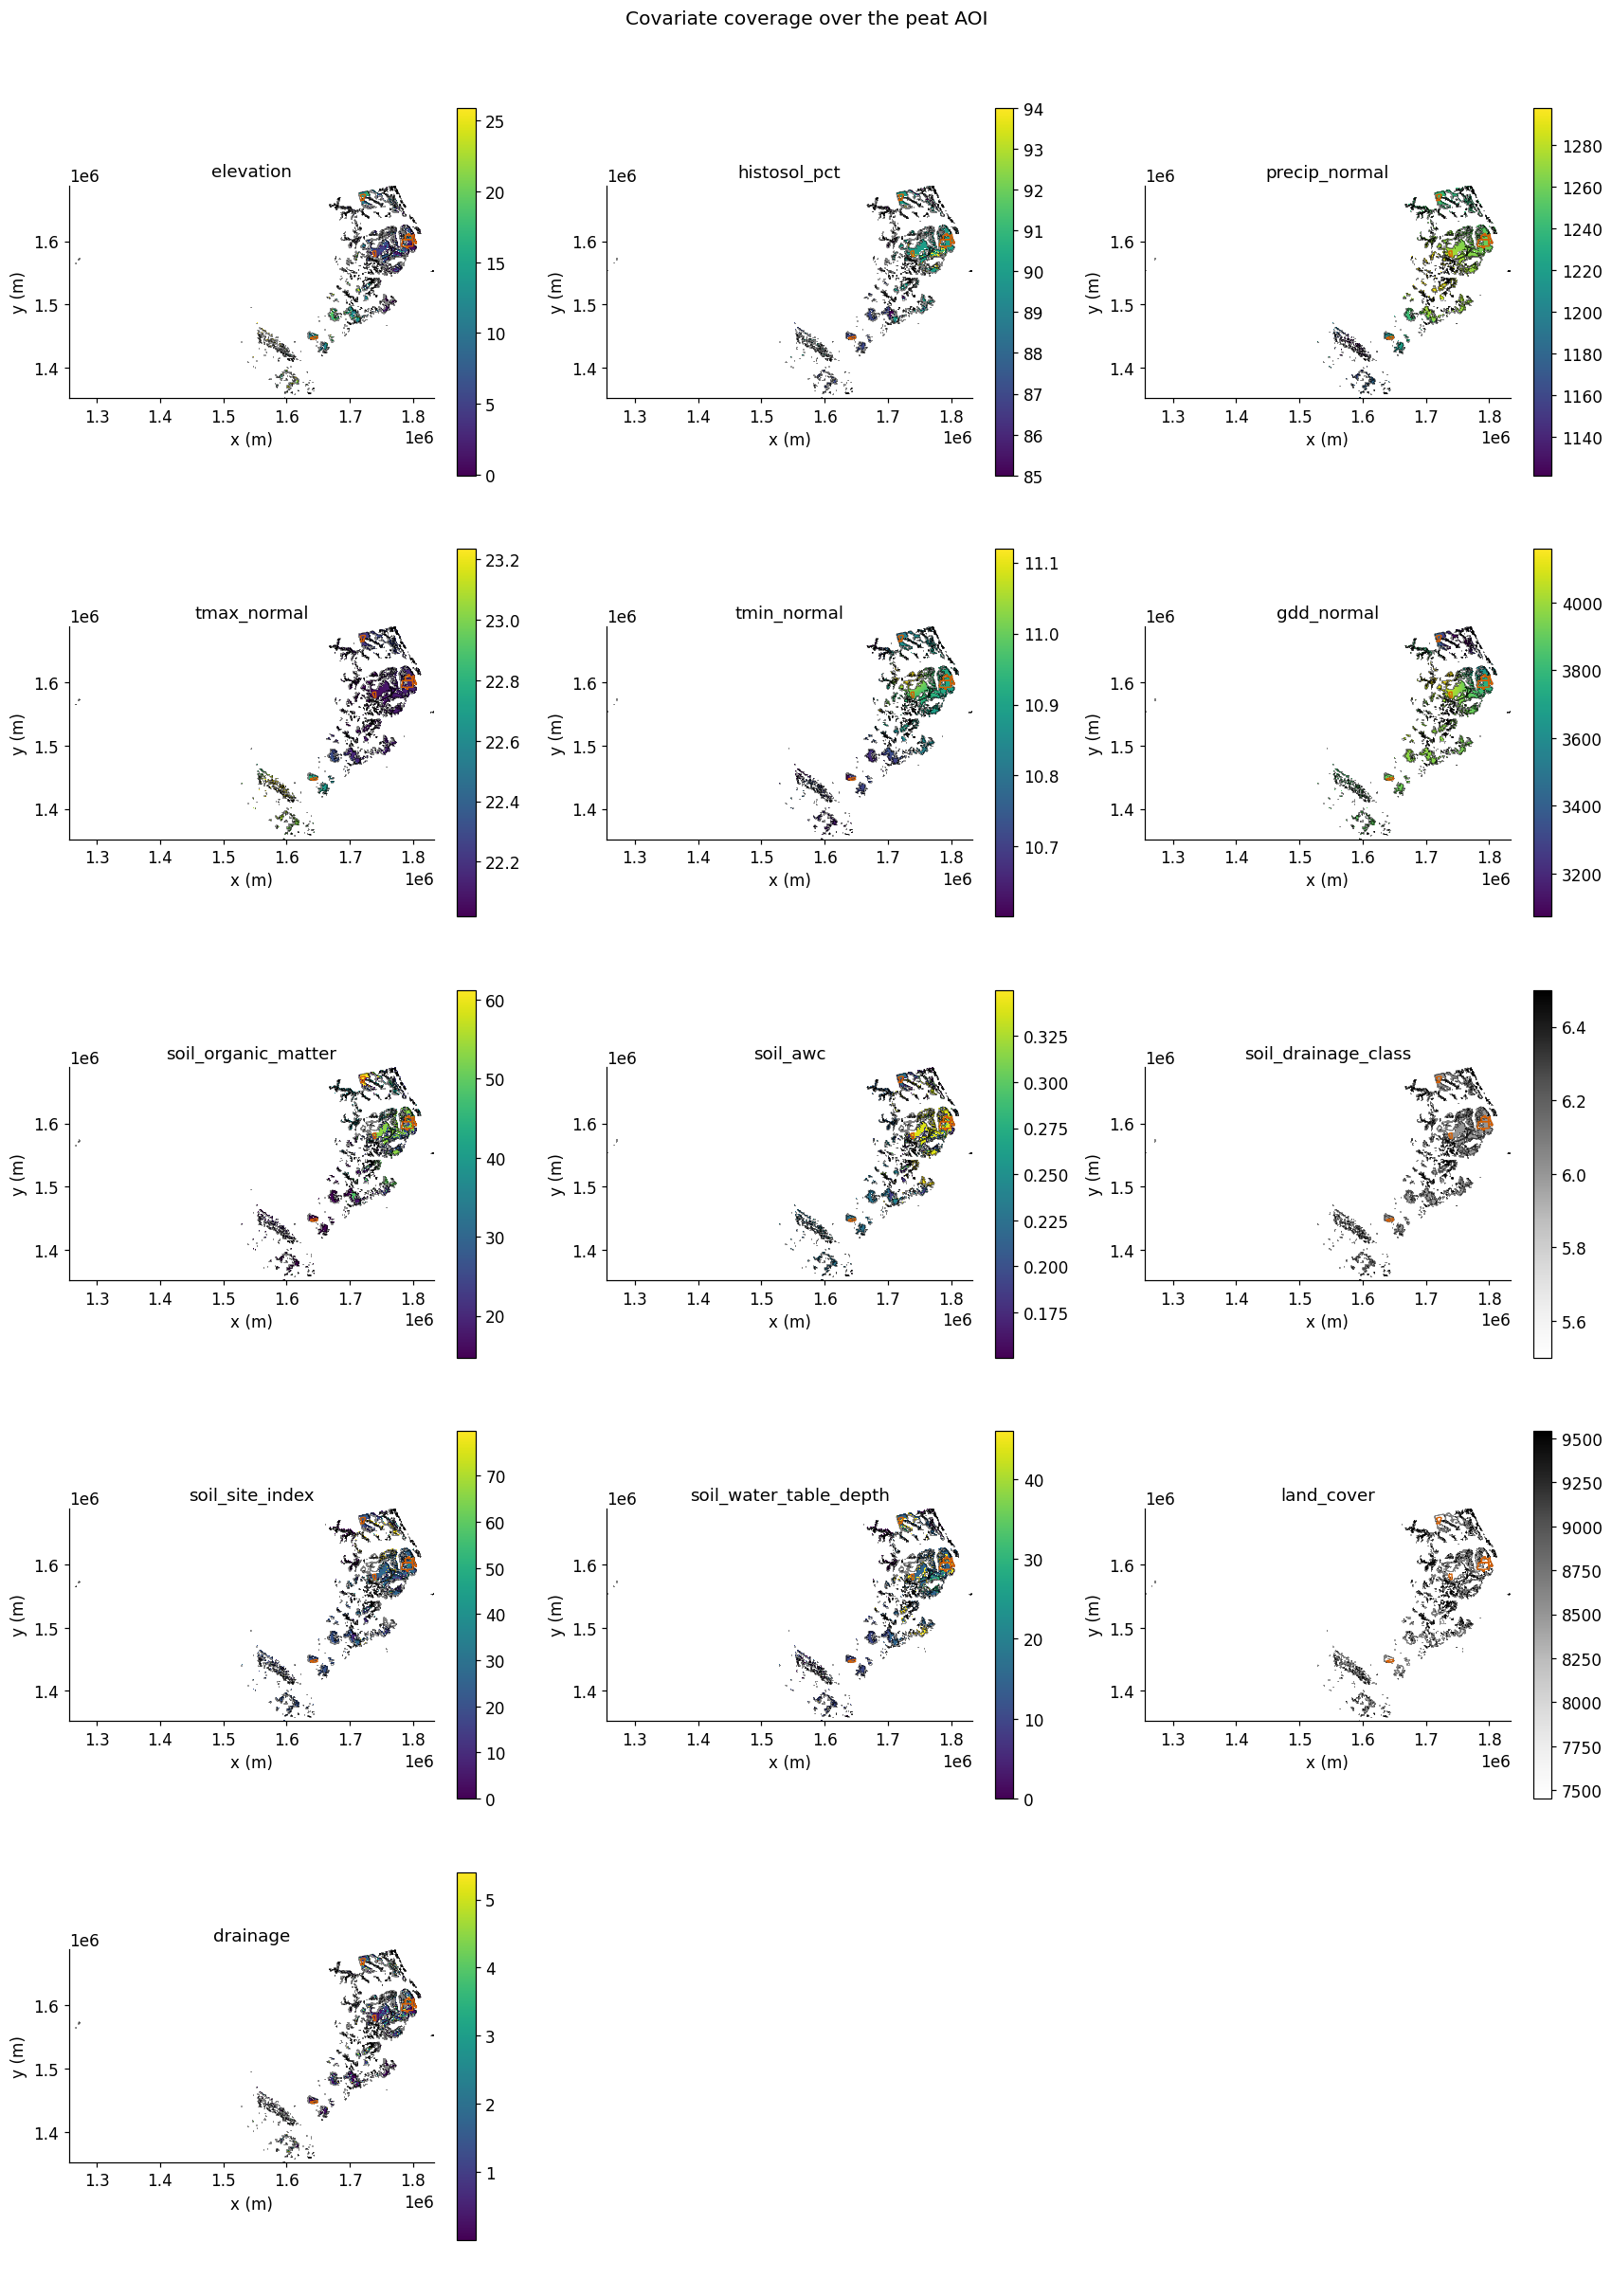

In [4]:
# Choose the outcome product once. Every downstream grid, response, score,
# match, and model cell reads these values; restart the kernel and rerun from here
# when switching products so 300 m and 500 m intermediate objects are not mixed.
FIRE_PRODUCT = "MCD64A1"  # change to "MCD64A1" for the long-record analysis
FIRE_PRODUCT_CONFIG = {
    "FireCCIS311": {"years": range(2019, 2027), "res_m": 300},
    "MCD64A1": {"years": range(2001, 2027), "res_m": 500},
}
if FIRE_PRODUCT not in FIRE_PRODUCT_CONFIG:
    raise ValueError(f"configure years/resolution for {FIRE_PRODUCT!r}")

fire_product = FIRE_PRODUCT
YEARS = FIRE_PRODUCT_CONFIG[fire_product]["years"]
RES_M = FIRE_PRODUCT_CONFIG[fire_product]["res_m"]
# Covariate exclusions -- see methods.md 5.4. Two independent reasons:
#   * climate: keep scPDSI + GDD as the ONLY climate predictors and drop the raw
#     temperature/precipitation metrics, which are strongly collinear with them
#     and with each other (TNC request, C. Chamberlain, Aug 2026). This covers
#     both the static normals and their per-year counterparts.
#   * soil_water_table_depth: a positivity failure -- control pixels got near-zero
#     propensity for the later cohorts, so the overlap the DR estimator needs was
#     not there.
# Every downstream stage (match axes, score inputs, DiD covariates, the frame, and
# the logistic adjustment set) filters against this one set.
excluded_covariates = {
    "soil_water_table_depth",                       # positivity failure
    "precip_normal", "tmax_normal", "tmin_normal",  # static: collinear with GDD
    "precip", "tmax", "tmin",                       # per-year: collinear with PDSI
}

cluster_by = 'site'

print(f"outcome: {fire_product} | years: {min(YEARS)}--{max(YEARS)} | grid: {RES_M} m")

# --- Climate from the GHCN .Rds long tables (one per element) ------------------
# load_ghcn_stations reads .Rds directly (via pyreadr): each long table carries
# one value column (PRCP / TMAX / TMIN) plus station lon/lat and a YEAR. The same
# loaded station frames feed two products:
#   * build_climate_normals -> a long-run NORMAL per pixel (STATIC): the stable
#     site climate the geographic MATCH keys off (precip_normal / tmax_normal /
#     tmin_normal in processed/climate/).
#   * build_annual_climate  -> one grid per (element, YEAR) (TEMPORAL): the
#     year-specific weather the OUTCOME / DiD stage uses (a treated:precip dry-year
#     interaction), written to processed/climate/annual/ as precip_<year>_nc.tif ...
#     and registered as the temporal covariates precip / tmax / tmin.
ghcn = data_path("interim", "climate", "ghcn")
try:
    prcp = climate.load_ghcn_stations(ghcn / "nc_prcp_long.Rds")
    tmax = climate.load_ghcn_stations(ghcn / "nc_tmax_long.Rds")
    tmin = climate.load_ghcn_stations(ghcn / "nc_tmin_long.Rds")

    # Static normals for matching (mean over the 1991-2020 baseline).
    normals = climate.build_climate_normals(
        {"precip_normal": prcp, "tmax_normal": tmax, "tmin_normal": tmin},
        aoi_nc_peat_80_histosol,
        res_m=RES_M, baseline=(1991, 2020),   # None = use every year present
    )
    written = climate.write_climate_normals(normals)
    print("wrote climate normals:", {k: p.name for k, p in written.items()})

    # Per-year weather for the outcome / DiD stage.
    annual = climate.build_annual_climate(
        {"precip": prcp, "tmax": tmax, "tmin": tmin},
        aoi_nc_peat_80_histosol,
        years=YEARS, res_m=RES_M,
    )
    written_annual = climate.write_annual_climate(annual)
    print(f"wrote {len(written_annual)} per-year climate rasters: "
          f"{sorted({e for e, _ in written_annual})} x "
          f"{sorted({y for _, y in written_annual})}")
except (FileNotFoundError, ValueError) as e:
    print("climate build skipped:", e)

# --- Growing degree days normal (STATIC), from Cat's monthly climate export ----
# clim_monthly.gpkg (get_climate&soil_data_updated.R) carries a per-station-year
# totalGDD (base 5 C growing-season warmth). Same station -> normal -> IDW path as
# the temperature normals, but its own file: it has no STATION column
# (load_ghcn_stations falls back to a per-point id) and a lowercase `year`, so pass
# year_col="year". Registers as the static covariate `gdd_normal`.
try:
    gdd_records = climate.load_ghcn_stations(ghcn / "clim_monthly.gpkg")
    gdd_normal = climate.build_climate_normals(
        {"gdd_normal": gdd_records},
        aoi_nc_peat_80_histosol,
        elements=climate.DEFAULT_GDD_ELEMENTS,   # totalGDD -> across-years mean
        res_m=RES_M, year_col="year", baseline=(1991, 2020),
    )
    written_gdd = climate.write_climate_normals(gdd_normal)
    print("wrote GDD normal:", {k: p.name for k, p in written_gdd.items()})

    # --- and the PER-YEAR counterpart (TEMPORAL) ------------------------------
    # Same station records and the same totalGDD column, but build_annual_climate
    # keeps each calendar year separate instead of averaging across them, writing
    # processed/climate/annual/gdd_<year>_nc.tif -> the temporal covariate `gdd`.
    # This is what gives GDD the same static/temporal pair scPDSI and precip have:
    # `gdd_normal` is the stable site warmth the geographic MATCH keys off, `gdd` is
    # the individual year's warmth the OUTCOME stage uses (treated:gdd, the warmth
    # analogue of treated:pdsi). Note per-year GDD is noisier than the normal --
    # totalGDD accumulates over whatever days a station reported, so a gappy
    # station-year under-counts, and averaging across years no longer damps it.
    annual_gdd = climate.build_annual_climate(
        {"gdd": gdd_records},
        aoi_nc_peat_80_histosol,
        years=YEARS, res_m=RES_M, year_col="year",
        elements=climate.DEFAULT_ANNUAL_GDD_ELEMENTS,   # totalGDD -> that year's GDD
    )
    written_annual_gdd = climate.write_annual_climate(annual_gdd)
    print(f"wrote {len(written_annual_gdd)} per-year GDD rasters: "
          f"{sorted({y for _, y in written_annual_gdd})}")
except (FileNotFoundError, ValueError, ImportError) as e:
    print("GDD build skipped:", e)

# --- scPDSI drought index, per year (TEMPORAL) --------------------------------
# The Palmer Drought Severity Index comes off its own long table (nc_pdsi_long.Rds,
# one row per station-MONTH, written by get_climate&soil_data.R). It reuses the same
# station -> annual-value -> IDW path as precip/tmax, but as a per-year layer only:
# scPDSI is self-calibrating (~0 = normal, negative = drought), so a long-run normal
# is ~0 everywhere -- there is no `pdsi_normal` to match on. It is registered as the
# temporal covariate `pdsi` and enters the DiD / outcome stage as a treated:pdsi
# drought-year interaction (the drought analogue of treated:precip).
try:
    pdsi_records = climate.load_ghcn_stations(ghcn / "nc_pdsi_long.Rds")
    annual_pdsi = climate.build_annual_climate(
        {"pdsi": pdsi_records},
        aoi_nc_peat_80_histosol,
        years=YEARS, res_m=RES_M,
        elements=climate.DEFAULT_PDSI_ELEMENTS,   # scPDSI -> annual mean
    )
    written_pdsi = climate.write_annual_climate(annual_pdsi)
    print(f"wrote {len(written_pdsi)} per-year scPDSI rasters: "
          f"{sorted({y for _, y in written_pdsi})}")
except (FileNotFoundError, ValueError, ImportError) as e:
    print("scPDSI build skipped:", e)

# --- Soil covariates from the SSURGO GeoPackage (polygons, not a raster) -------
# Inspect the attribute columns first, then rasterise the ones you want onto the
# grid. The defaults (om_r, awc_r, drainagecl) are standard gSSURGO names; if your
# export differs, the printed columns tell you what to pass as `attributes=`.
soil_gpkg = data_path("interim", "soil", "ssurgo", "nc_soil_ssurgo.gpkg")
try:
    inspect_soil_columns(soil_gpkg)                    # <- read the columns here
    build_soil_rasters(soil_gpkg, aoi_nc_peat_80_histosol, res_m=RES_M)

    # Augment with the two extra properties on Cat's aggregated soil_database.gpkg
    # (site index + water-table depth) from get_climate&soil_data_updated.R. They
    # sit directly on the polygons, so build_soil_database_rasters reads them with
    # no MUKEY aggregation and writes ssurgo_site_index / ssurgo_water_table_depth
    # -> the covariates soil_site_index + soil_water_table_depth.
    soil_db_gpkg = data_path("interim", "soil", "ssurgo", "soil_database.gpkg")
    if soil_db_gpkg.exists():
        build_soil_database_rasters(soil_db_gpkg, aoi_nc_peat_80_histosol, res_m=RES_M)
    else:
        print("soil_database.gpkg not found -- run get_climate&soil_data_updated.R "
              "to add soil_site_index + soil_water_table_depth.")
except Exception as e:
    print("soil build skipped:", e)

print("covariates on disk now:", available_covariates())

# Map every covariate on disk (elevation, histosol %, climate normals, soil). A
# visually flat panel = a covariate with no spatial signal to match on.
fig = plot_covariate_maps(
    aoi_nc_peat_80_histosol,
    names=available_covariates(),
    res_m=RES_M,
    treated=peat_restoration,          # outline restoration sites for context
)
fig.savefig(FIG_DIR / "covariate_maps.png", bbox_inches="tight")
print("saved", FIG_DIR / "covariate_maps.png")

### The temporal covariates: drought (scPDSI) and warmth (GDD) by year

`plot_covariate_maps` above maps only the **static** match layers, so the
per-year weather in `TEMPORAL_COVARIATES` -- `precip` / `tmax` / `tmin` / `pdsi` /
`gdd` -- never appears there. This is the only place to see it, and the cell below
draws one figure per per-year layer that survives the 5.4 exclusions:

* **`pdsi`** -- annual-mean scPDSI. It has *no* static-normal counterpart at all:
  scPDSI is self-calibrating, so every station's long-run mean is ~0 by
  construction and a `pdsi_normal` would be a flat zero surface with nothing to
  match on. Drawn on a single zero-centred scale (red = drought, blue = wet).
* **`gdd`** -- that year's accumulated growing degree days. Unlike `pdsi` it *does*
  have a static counterpart (`gdd_normal`, mapped with the match layers above);
  the two are the between-site and within-site halves of the same signal.

Either way `plot_temporal_covariate_by_year` puts every panel on one shared scale
so the years are comparable, which is the spatial+temporal weather signal the
outcome stage keys off via the `treated:pdsi` / `treated:gdd` interactions.
`available_temporal_covariates(YEARS)` confirms which per-year layers actually
built for **every** panel year before we plot.

In [5]:
 
print("temporal covariates on disk for every panel year:",
      available_temporal_covariates(YEARS))

# One map-per-year figure per temporal covariate that survives the 5.4 exclusions
# (`pdsi` and `gdd`). Each is drawn on a single scale shared across all its panels,
# so years are comparable: scPDSI is signed, so it auto-centres on 0 (red = drought,
# blue = wet); GDD is strictly positive, so it falls back to a robust sequential
# scale (bright = a warm year / warm end of the AOI).
for _name in [c for c in available_temporal_covariates(YEARS)
              if c not in excluded_covariates]:
    fig = plot_temporal_covariate_by_year(
        aoi_nc_peat_80_histosol,
        _name,
        YEARS,
        res_m=RES_M,
        treated=peat_restoration,      # outline restoration sites for context
    )
    fig.savefig(FIG_DIR / f"{_name}_by_year.png", bbox_inches="tight")
    plt.close(fig)                 # a 20+ panel figure per covariate -> save, don't hold
    print("saved", FIG_DIR / f"{_name}_by_year.png")

temporal covariates on disk for every panel year: ['precip', 'tmax', 'tmin', 'pdsi', 'gdd']
saved /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/outputs/figures/modeling/pdsi_by_year.png
saved /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/outputs/figures/modeling/gdd_by_year.png


### Inspect the raw GHCN climate tables (precip, tmin, tmax)

The three `nc_*_long.Rds` files are the **raw station-day records** behind the
`precip`/`tmax`/`tmin` layers: one row per (station, day), already unit-converted
in R (precip -> mm, temps -> deg C). `load_ghcn_stations` reads them and reprojects
the station points to EPSG:5070. These are the frames the normals (1991-2020 mean)
and the per-year weather grids are both reduced from -- inspect them here before
they're collapsed.


In [6]:
# Load the three raw GHCN long tables for inspection (independent of the build
# above, so this cell stands on its own). Each is one row per station-day.
ghcn = data_path("interim", "climate", "ghcn")
raw_climate = {}
for element, fname in [("precip", "nc_prcp_long.Rds"),
                       ("tmax", "nc_tmax_long.Rds"),
                       ("tmin", "nc_tmin_long.Rds")]:
    try:
        raw_climate[element] = climate.load_ghcn_stations(ghcn / fname)
    except (FileNotFoundError, ValueError, ImportError) as e:
        print(f"{element}: could not load {fname} -- {e}")

for element, df in raw_climate.items():
    value_col = {"precip": "PRCP", "tmax": "TMAX", "tmin": "TMIN"}[element]
    n_station = df["STATION"].nunique() if "STATION" in df.columns else "?"
    if "YEAR" in df.columns:
        yr = df["YEAR"].dropna()
        year_span = f"{int(yr.min())}-{int(yr.max())}" if len(yr) else "?"
    else:
        year_span = "?"
    print(f"\n=== {element} ({value_col}) ===")
    print(f"  rows: {len(df):,}  |  stations: {n_station}  |  years: {year_span}")
    print("  columns:", list(df.columns))
    if value_col in df.columns:
        print(df[value_col].describe().to_string())

# Show one frame in full (precip if present) so you can eyeball the row structure.
_first = next(iter(raw_climate.values())) if raw_climate else None
if _first is not None:
    display(_first.head(10))



=== precip (PRCP) ===
  rows: 519,848  |  stations: 18  |  years: 1926-2026
  columns: ['STATION', 'YEAR', 'MONTH', 'DAY', 'PRCP', 'NAME', 'geometry']
count    519848.000000
mean          3.358486
std           9.844069
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max        1527.800000

=== tmax (TMAX) ===
  rows: 520,553  |  stations: 18  |  years: 1926-2026
  columns: ['STATION', 'YEAR', 'MONTH', 'DAY', 'TMAX', 'NAME', 'geometry']
count    520553.000000
mean         22.351426
std           9.060730
min         -62.200000
25%          16.100000
50%          23.900000
75%          29.400000
max        1470.000000

=== tmin (TMIN) ===
  rows: 519,514  |  stations: 18  |  years: 1926-2026
  columns: ['STATION', 'YEAR', 'MONTH', 'DAY', 'TMIN', 'NAME', 'geometry']
count    519514.000000
mean          9.604885
std           9.026713
min         -51.100000
25%           2.200000
50%          10.000000
75%          17.800000
max          50.600

,STATION,YEAR,MONTH,DAY,PRCP,NAME,geometry
1,USC00312719,1926,01,1.0,0.0,ELIZABETH CITY,POINT (1748537.798 1656190.608)
2,USC00312719,1926,01,2.0,0.0,ELIZABETH CITY,POINT (1748537.798 1656190.608)
3,USC00312719,1926,01,3.0,0.0,ELIZABETH CITY,POINT (1748537.798 1656190.608)
4,USC00312719,1926,01,4.0,7.6,ELIZABETH CITY,POINT (1748537.798 1656190.608)
5,USC00312719,1926,01,5.0,6.4,ELIZABETH CITY,POINT (1748537.798 1656190.608)
6,USC00312719,1926,01,6.0,3.8,ELIZABETH CITY,POINT (1748537.798 1656190.608)
7,USC00312719,1926,01,7.0,0.0,ELIZABETH CITY,POINT (1748537.798 1656190.608)
8,USC00312719,1926,01,8.0,16.5,ELIZABETH CITY,POINT (1748537.798 1656190.608)
9,USC00312719,1926,01,9.0,0.0,ELIZABETH CITY,POINT (1748537.798 1656190.608)
10,USC00312719,1926,01,10.0,0.0,ELIZABETH CITY,POINT (1748537.798 1656190.608)


In [7]:
inspect_soil_columns()

nc_soil_ssurgo.gpkg: 341,835 polygons, 4 polygon columns
    column   dtype  n_unique  n_null                           sample
AREASYMBOL     str        40       0     [NC013, NC015, NC017, NC019]
SPATIALVER float64        10       0           [4.0, 8.0, 14.0, 11.0]
     MUSYM     str       585       0               [StA, Le, Sb, TaB]
     MUKEY     str      1809       0 [111607, 111581, 111605, 111611]

5 layers total; soil properties are in the attribute tables:
  soil_organic_matter    column 'om_r'         -> found in 'chorizon' (aggregated to MUKEY)
  soil_awc               column 'awc_r'        -> found in 'chorizon' (aggregated to MUKEY)
  soil_drainage_class    column 'drainagecl'   -> found in 'component' (aggregated to MUKEY)


,column,dtype,n_unique,n_null,sample
0,AREASYMBOL,str,40,0,"[NC013, NC015, NC017, NC019]"
1,SPATIALVER,float64,10,0,"[4.0, 8.0, 14.0, 11.0]"
2,MUSYM,str,585,0,"[StA, Le, Sb, TaB]"
3,MUKEY,str,1809,0,"[111607, 111581, 111605, 111611]"


## 2. Build matched controls

**a. Clip-to-drop** the restoration sites (plus a buffer) from the peat frame to
get the control *candidate* pool. `how="difference"` is the inverse of clip:

```python
BUFFER_M = 1000  # exclusion halo around restoration sites, in metres
exclusion = gpd.GeoDataFrame(geometry=[restoration.buffer(BUFFER_M).union_all()],
                             crs=restoration.crs)
candidates = gpd.overlay(aoi_nc_peat_80_histosol, exclusion, how="difference")
```

**b. Candidate pixels + nearest site.** Turn candidate peat into pixel points
(e.g. centroids of the grid cells over `candidates`), then attach each one's
nearest restoration site and distance in one call:

```python
cand_pts = gpd.sjoin_nearest(candidate_points, restoration,
                             how="left", distance_col="dist_m")
```

**c. Sample covariates** at treated and candidate pixels (reuse the grid warp):
`covariate_on_grid('elevation', grid, aoi)` and `('histosol_pct', ...)`, then
read values at the pixel locations. Assemble a table with a `treatment` 0/1
column + `elevation`, `histosol_pct`.

**d. Match** treated<->control on those covariates. Two options:
- literal nearest-neighbour on z-scored covariates: `sklearn.neighbors.NearestNeighbors`
- propensity score: `pymatch.Matcher(...).fit_scores(); .match(); .matched_data`
  (matches on P(treatment), not raw covariates -- know the difference).

Output of this section: a `units` GeoDataFrame with **`treated`** (1/0),
**`site_id`** (the matched stratum), and **`unit_id`** columns. That is all
`build_frame` needs.

In [8]:

spillover_m = 0 # set to 0 cuz TNC does a good job at preventing spillover into neighboring communities
# RES_M (300 m) and YEARS (2019-2024, the FireCCIS311 coverage) come from step 1b.

# Match on every CONTINUOUS covariate on disk: elevation + histosol %, plus the
# climate normals and SSURGO soil layers built/registered above. This is what
# breaks the 'match on elevation alone' degeneracy -- histosol % is ~constant on
# the 80% frame, so without climate/soil the whitened distance had only elevation
# to work with. Categorical layers (drainage class, land cover) become exact-match
# keys in match_controls, not continuous axes here.
_on_disk = set(available_covariates())
covariates = [c for c in list_covariates('continuous') if c in _on_disk and c not in excluded_covariates]
if not covariates:                 # safety net if nothing resolved
    covariates = ['histosol_pct', 'elevation']
# Categorical soil/land-cover layers become EXACT-match keys (matched within
# class), not continuous distance axes.
categorical = [c for c in list_covariates('categorical') if c in _on_disk and c not in excluded_covariates]
print('matching on continuous covariates:', covariates)
print('exact-match (categorical) keys:', categorical)

# Pixel-YEAR panel (not a single flattened set): every candidate pixel is
# repeated once per calendar year, with
#   - `treated`                  1 once the pixel's site has been restored, else 0
#   - `<restoration_yr_col>`      the site's End_Yr (NaN for control-pool pixels)
#   - `years_after_restoration`  = year - End_Yr  (0 = restoration year,
#                                  matching the notebook's event_year convention)
# Control pixels appear in every year with treated=0. Pre-restoration site
# pixels are kept as *not-yet-treated* controls for the staggered DiD below
# (pass drop_pretreatment=True for the simpler restored-by-year-Y cross-section).
pixels = get_treated_and_control_pixels(
    aoi_nc_peat_80_histosol,
    peat_restoration,
    years=YEARS,
    spillover_m=spillover_m,
    res_m=RES_M,
    treated_col_name="treated",
    restoration_yr_col=restoration_yr_col,   # 'End_Yr', kept under this name
    site_col="Proj_Name",
)

# Per-year (temporal) layers, filtered by the SAME exclusion set -- otherwise
# attach_covariates defaults to every per-year layer on disk and would re-attach
# the precip/tmax/tmin weather that 5.4 drops. After the exclusions this is `pdsi`
# + `gdd`, the two retained climate predictors in their year-varying form, which is
# what the outcome stage wants. (The match itself keys off the STATIC list above --
# `gdd_normal`, not `gdd`: matching on a year-varying value would pair pixels on
# weather that partly post-dates restoration.)
temporal_covariates = [c for c in available_temporal_covariates(YEARS)
                       if c not in excluded_covariates]
print('per-year (temporal) covariates:', temporal_covariates)

# Static covariates are sampled once per pixel and broadcast across the years.
pixels_with_covariates = attach_covariates(
    pixels, [*covariates, *categorical], aoi_nc_peat_80_histosol, RES_M,
    temporal_names=temporal_covariates,
)

print(pixels_with_covariates.shape)
print("treated pixel-years by calendar year:")
print(pixels_with_covariates.groupby("year")["treated"].sum())
pixels_with_covariates.head()


/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:371: UserWarning: management: directory /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/processed/management/seus_forest_mgmt does not exist -- skipping.
  return [name for name, spec in COVARIATES.items() if _covariate_file(spec)]


matching on continuous covariates: ['elevation', 'histosol_pct', 'gdd_normal', 'soil_organic_matter', 'soil_awc', 'soil_site_index', 'drainage']
exact-match (categorical) keys: ['soil_drainage_class', 'land_cover']
per-year (temporal) covariates: ['pdsi', 'gdd']
(560066, 19)
treated pixel-years by calendar year:
year
2001       0
2002       0
2003       0
2004       0
2005       0
2006       0
2007       0
2008       0
2009       0
2010       0
2011       0
2012       0
2013       0
2014       0
2015       0
2016       0
2017       0
2018       0
2019    1247
2020    1247
2021    1386
2022    1386
2023    1586
2024    1586
2025    1586
2026    1707
Name: treated, dtype: int64


,x,y,geometry,End_Yr,Proj_Name,year,years_after_restoration,treated,elevation,histosol_pct,gdd_normal,soil_organic_matter,soil_awc,soil_site_index,drainage,soil_drainage_class,land_cover,pdsi,gdd
0,1.795560e+06,1.599776e+06,POINT (1795560.262 1599775.871),2019.0,Dare Bombing Range WMP,2001,-18.0,0,3.918629,90.0,3747.129395,24.981268,0.18445,19.767443,2.098124,6.0,7452.0,-2.148697,4008.436035
1,1.789060e+06,1.598776e+06,POINT (1789060.262 1598775.871),2019.0,Dare Bombing Range WMP,2001,-18.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.788560e+06,1.598776e+06,POINT (1788560.262 1598775.871),2019.0,Dare Bombing Range WMP,2001,-18.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.788060e+06,1.598776e+06,POINT (1788060.262 1598775.871),2019.0,Dare Bombing Range WMP,2001,-18.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.787560e+06,1.598776e+06,POINT (1787560.262 1598775.871),2019.0,Dare Bombing Range WMP,2001,-18.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Inspect treated vs control in covariate space

Before matching, look at the two groups in covariate space. A **flat axis** is a
covariate with no spread (nothing to match on there); with climate + soil added,
treated and control should now separate on more than just elevation. The scatter
matrix shows every covariate axis at once.

saved covariate-space diagnostics -> /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/outputs/figures/modeling


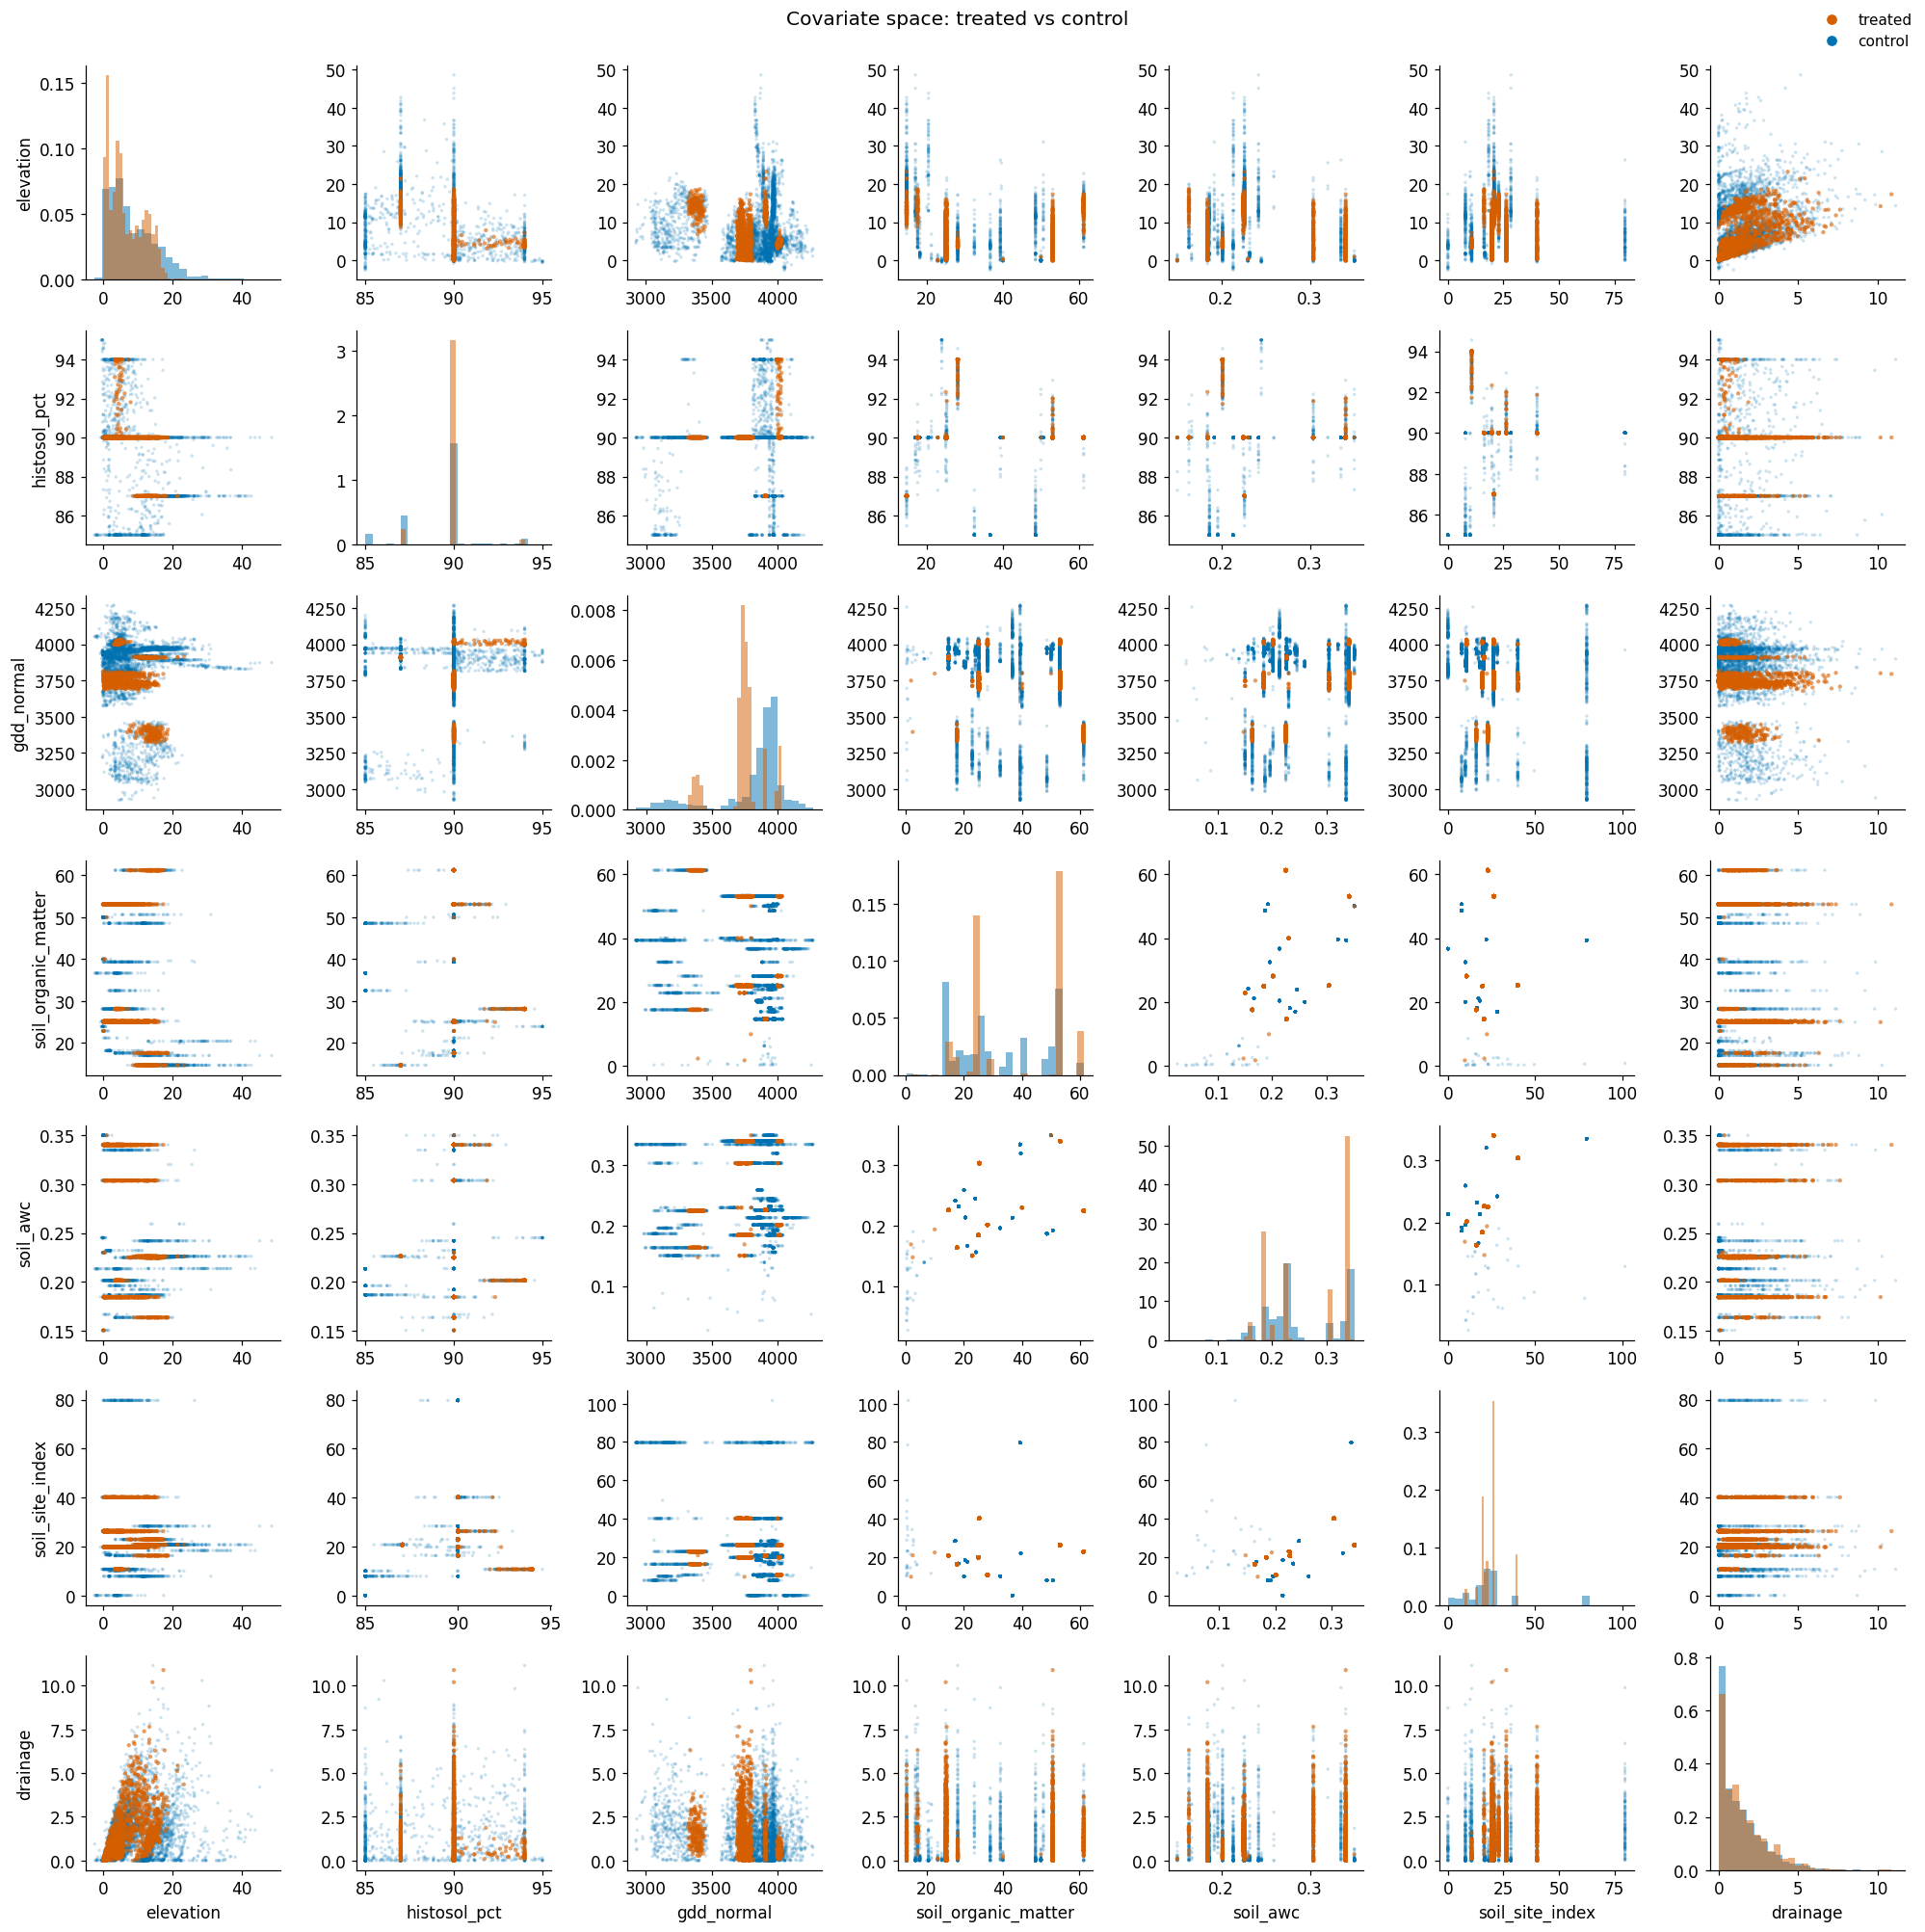

In [9]:
if {"soil_water_table_depth", "drainage"} in covariates:
    fig = plot_covariate_space(
        pixels_with_covariates, "soil_water_table_depth", "drainage",
        restoration_yr_col=restoration_yr_col,
    )
    fig.savefig(FIG_DIR / "covariate_space_soil_water_table_depth_drainage.png", bbox_inches="tight")

if len(covariates) >= 2:
    fig = plot_covariate_pairs(
        pixels_with_covariates, covariates, restoration_yr_col=restoration_yr_col,
    )
    fig.savefig(FIG_DIR / "covariate_pairs.png", bbox_inches="tight")
print("saved covariate-space diagnostics ->", FIG_DIR)

## 2b. Product-supported event-time panel → staggered DiD

The selected fire product determines which restoration cohorts can identify a
pre/post effect. Before scoring or matching, `restrict_to_supported_cohorts`
keeps never-treated controls and only cohorts satisfying
`first outcome year < g <= last outcome year`. Thus FireCCIS311 (2019–2024)
uses the 2021/2023 cohorts in these data and excludes 2019 (no pre-period) and
2026 (no post-period); MCD64A1 (configured as 2001–2024) additionally recovers
the 2019 cohort. This restriction changes the FireCCIS311 estimand to the ATT
for its supported, later restoration cohorts.

The retained pixel-year panel carries the per-pixel `treated` switch and fixed
restoration cohort `g`. We attach the selected fire response, assign stable
`unit_id`s, and fit Callaway–Sant'Anna group-time effects with standard errors
clustered by restoration site (`site_id`). When changing `FIRE_PRODUCT`, restart
the kernel and rerun from the configuration cell so grids and matches are rebuilt
at the selected product's resolution.


In [10]:
# Restrict cohorts BEFORE scores/matching. Controls (null End_Yr) remain in the
# candidate pool; unsupported treated cohorts are removed with a warning. For the
# current data FireCCIS311 retains 2021/2023, while MCD64A1 also retains 2019.
pixels_did = did.restrict_to_supported_cohorts(
    pixels_with_covariates,
    years=YEARS,
    restoration_yr_col=restoration_yr_col,
)

# Attach the selected product's annual 0/1 response. The product is configured
# once above; do not reset fire_product here.
panel = attach_fire_response(
    pixels_did, aoi_nc_peat_80_histosol,
    product=fire_product, res_m=RES_M,
)
panel = did.prepare_panel(
    panel, restoration_yr_col=restoration_yr_col, site_col="Proj_Name"
)

print("outcome product:", fire_product)
print("cohorts g:", sorted(panel["g"].unique()))
print("burned pixel-years with coverage:", int(panel["burned"].notna().sum()))
panel.head()


outcome product: MCD64A1
cohorts g: [np.int64(0), np.int64(2019), np.int64(2021), np.int64(2023), np.int64(2026)]
burned pixel-years with coverage: 560066


/var/folders/f0/1x9ky0yd3nj4p68sphk83ngr0000gn/T/ipykernel_69482/3106067836.py:16: UserWarning: 19834 pixel(s) have no 'Proj_Name' and so no restoration site to cluster with; each gets its own singleton 'site_id'. Match first (restrict_panel_to_matched) if you want controls to join their treated partner's site cluster.
  panel = did.prepare_panel(


,x,y,geometry,End_Yr,Proj_Name,year,years_after_restoration,treated,elevation,histosol_pct,...,soil_site_index,drainage,soil_drainage_class,land_cover,pdsi,gdd,burned,unit_id,g,site_id
0,1.795560e+06,1.599776e+06,POINT (1795560.262 1599775.871),2019.0,Dare Bombing Range WMP,2001,-18.0,0,3.918629,90.0,...,19.767443,2.098124,6.0,7452.0,-2.148697,4008.436035,0.0,20482,2019,Dare Bombing Range WMP
1,1.789060e+06,1.598776e+06,POINT (1789060.262 1598775.871),2019.0,Dare Bombing Range WMP,2001,-18.0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,19462,2019,Dare Bombing Range WMP
2,1.788560e+06,1.598776e+06,POINT (1788560.262 1598775.871),2019.0,Dare Bombing Range WMP,2001,-18.0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,19379,2019,Dare Bombing Range WMP
3,1.788060e+06,1.598776e+06,POINT (1788060.262 1598775.871),2019.0,Dare Bombing Range WMP,2001,-18.0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,19298,2019,Dare Bombing Range WMP
4,1.787560e+06,1.598776e+06,POINT (1787560.262 1598775.871),2019.0,Dare Bombing Range WMP,2001,-18.0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,19219,2019,Dare Bombing Range WMP


### Burned area vs the covariates, across years

The descriptive counterpart to the DiD above, over the **whole peat AOI** rather
than a treated/control contrast: how many hectares of NC peat did this fire
product burn, at which covariate levels, in which years? Nothing here is causal —
there is no treatment in these plots at all. They are the "is this covariate
interesting in the first place?" pictures that motivate what the DiD then tries to
identify.

`build_mask_frame` assembles the table once — one row per (300 m cell x year) for
every cell in the mask, carrying the burn flag, the static covariates, that year's
weather, and a constant `pixel_area_ha` — and everything below is drawn off it.

#### Two families of view, and why both exist

|  | what it does | keeps | works on |
|---|---|---|---|
| `vs_covariate`, `heatmap` | bins pixels **within** each year by covariate value | the **spatial** variation (~20k pixels/year) | static **and** temporal covariates |
| `by_year`, `annual` | collapses the whole mask to **one number** per year | the **year-to-year** variation (6 points) | temporal covariates only |

Most of the registry is static — elevation, histosol %, the climate normals, the
SSURGO soil layers, HAND drainage — and a static layer has the same mask-average
every single year. So the collapsed views go blank on them (all points land on one
vertical line, and the panel says so). They still vary across *space*, which is
exactly what the binned views use, and what the matching keys off.

#### Why the covariate gets binned

`burned` is a 0/1 flag per pixel-year, so a raw scatter of it against a covariate
is two horizontal stripes of dots and nothing else. Instead the covariate's range
is cut into **equal-count bins** — edges chosen so each bin holds the same number
of pixels, pooled across all years — and each bin is summarised into one number.
One bin = one point on the curve = one row of the heat map. Bin *widths* therefore
differ (narrow where pixels are dense, wide in the tails); that is why the heat
map's rows have uneven heights. `bins=8` is a fine default for the peat AOI; drop
it if the curves look jumpy, since fewer pixels per bin means a noisier point.

#### Reading each plot

* **`vs_covariate`** — covariate on x, burned area on y, one line per year (dark =
  early, bright = late), all-years curve in black. Read the **slope of the black
  curve**: that is the covariate's fire gradient, the raw shape the fitted
  coefficient later summarises. Then read the **spread of the coloured lines**
  around it — a year whose line departs from the pooled shape burned somewhere
  unusual for its covariate level. With `metric="area_ha"` the black curve is the
  *sum* over years, so it sits well above the individual years; pass
  `show_pooled=False` to zoom into them.
* **`heatmap`** — year on x, covariate on y, burning as colour (brighter = more).
  Read **where the bright band sits vertically** (which covariate level carries the
  fire) and whether it **drifts across columns**. A drifting band means the
  covariate–fire relationship is year-dependent; a stable bright row means it
  holds across years. Grey cells are not zeros — they are combinations with **no
  pixels at all**, which is normal for a temporal covariate (a drought year simply
  has no wet pixels anywhere in the AOI).
* **`by_year`** — annual burned-area bars with the mask-mean covariate on a twin
  axis. Read whether the **peaks line up**: tall bars sitting over the dry dips is
  the drought-drives-fire signal.
* **`annual`** — the same two numbers plotted against *each other*, one labelled
  point per year, joined in chronological order. The quickest "is there anything
  here?" glance. Six points total, so read the shape, never a fit.

#### What the three metrics are for

Burned area is a **count** of burned pixels, so it scales with how many pixels a
bin holds. Each metric divides out something different:

| `metric` | what the number is | divides out | reach for it when |
|---|---|---|---|
| `"area_ha"` | absolute burned hectares | nothing | you want the headline quantity — "how much peat burned here" |
| `"rate"` | burned fraction of the bin's pixels | the bin's size | you want "does fire *prefer* this covariate level", exposure-free |
| `"share"` | % of **that year's** burned area | the year's total | comparing where fire sat in covariate space across a huge fire year and a quiet one |

When the difference actually bites:

* **Categorical layers** (`soil_drainage_class`, `land_cover`) — classes are
  whatever size they are, often several-fold apart. "Poorly drained peat burned the
  most hectares" is partly just "there is far more poorly drained peat." Use
  `"rate"`.
* **Per-year lines of a temporal covariate** — the bin edges are fixed, but the
  pixels slosh between bins from year to year (in a drought year most of the AOI
  lands in the driest bins), so one year's line mixes burning with how much of the
  AOI was at that level that year.
* **Static continuous covariates** — no issue. Equal-count binning already gives
  every bin the same pixel count in every year, so `"area_ha"` and `"rate"` have
  the same shape.

On the heat map, `"share"` is usually the most readable: with `"area_ha"` a single
big fire year can dominate the colour scale and flatten every other column to
black.

#### Caveats

The `r` / `rho` annotated on the annual views are correlations over a handful of
**years** (n = 6), not over pixels — description, not inference. And all of this is
unadjusted and treatment-free: a covariate that tracks burning here may simply be
tracking *where the restoration sites are*. That is the confounding the matching
and the DiD's `treated:pdsi` interaction exist to handle.

/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:371: UserWarning: management: directory /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/processed/management/seus_forest_mgmt does not exist -- skipping.
  return [name for name, spec in COVARIATES.items() if _covariate_file(spec)]


mask pixel-years: 920296 | burned pixel-years: 5513 | total burned area (ha): 137825.0
cells per year: {2001: 35396, 2002: 35396, 2003: 35396, 2004: 35396, 2005: 35396, 2006: 35396, 2007: 35396, 2008: 35396, 2009: 35396, 2010: 35396, 2011: 35396, 2012: 35396, 2013: 35396, 2014: 35396, 2015: 35396, 2016: 35396, 2017: 35396, 2018: 35396, 2019: 35396, 2020: 35396, 2021: 35396, 2022: 35396, 2023: 35396, 2024: 35396, 2025: 35396, 2026: 35396}
saved 64 figures -> /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/outputs/figures/modeling


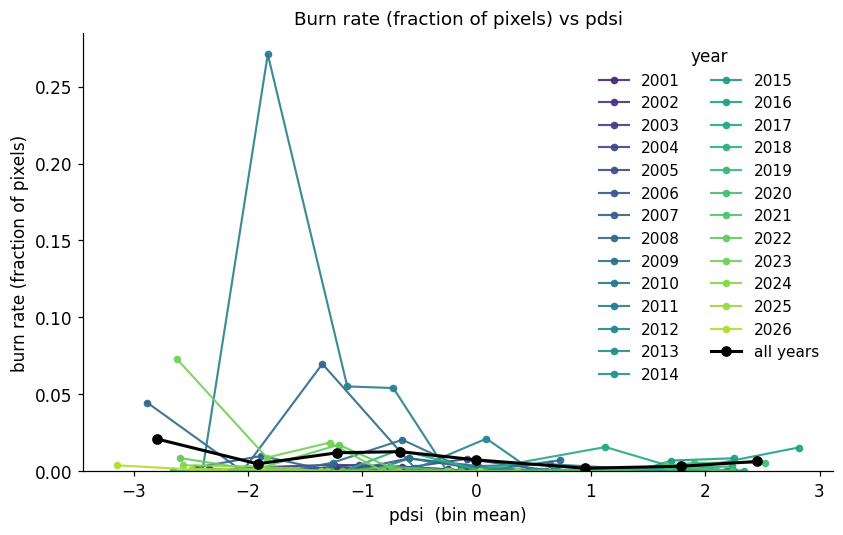

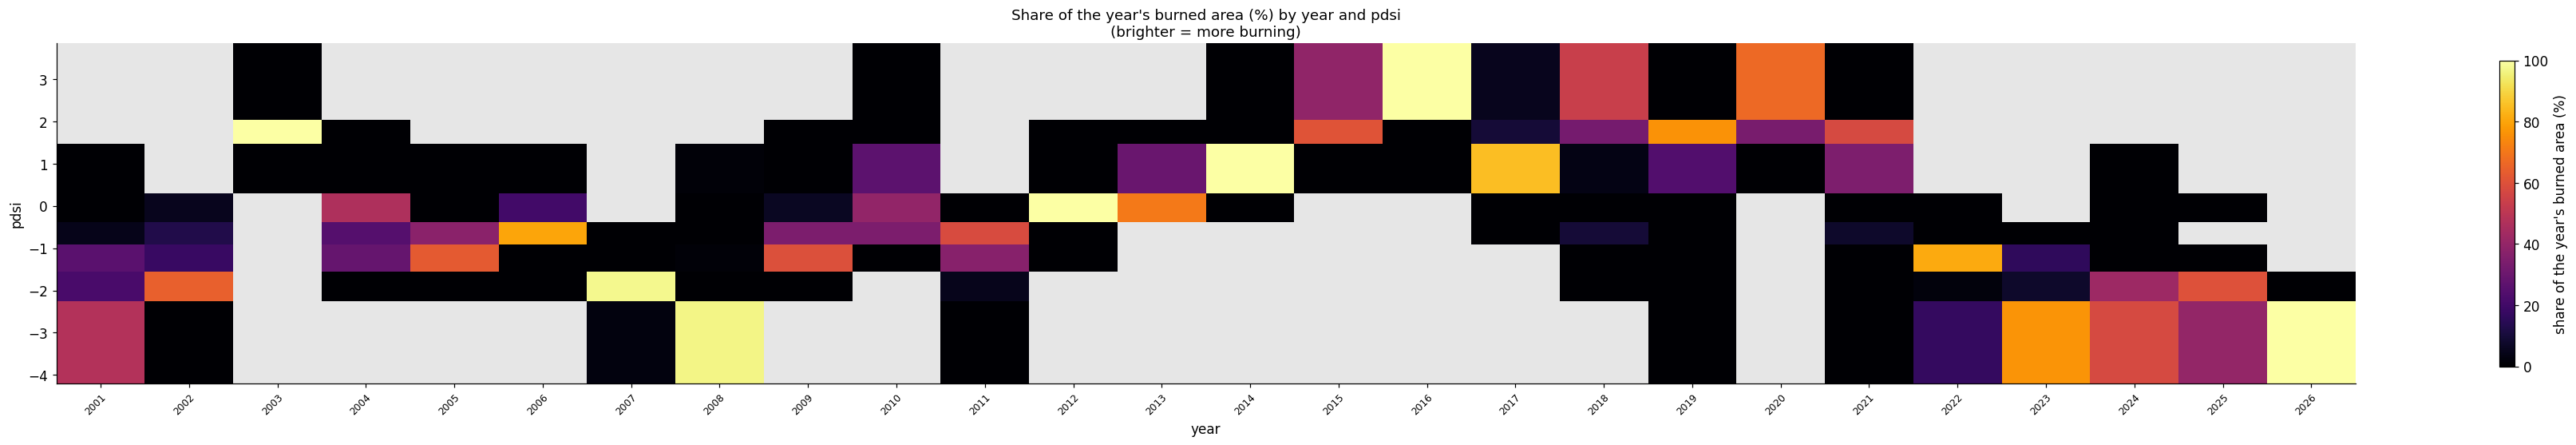

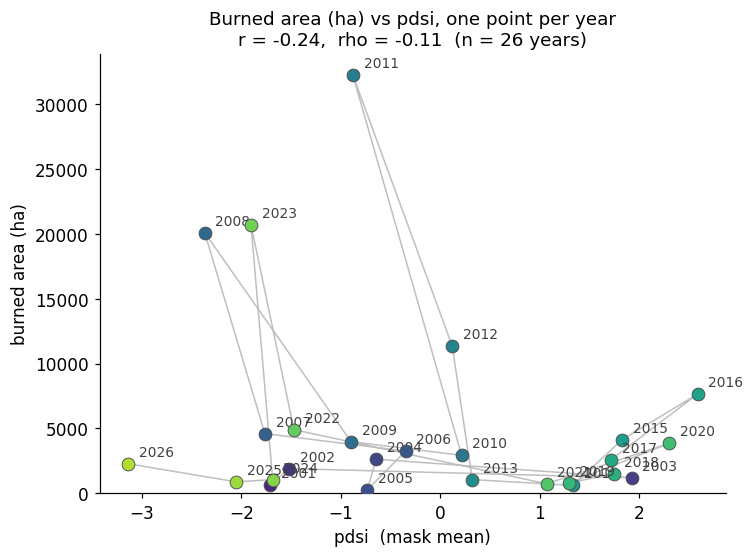

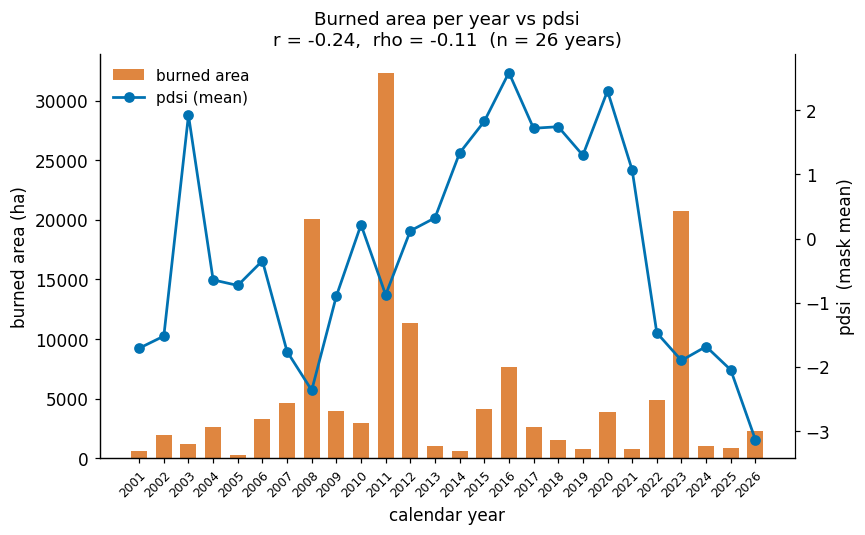

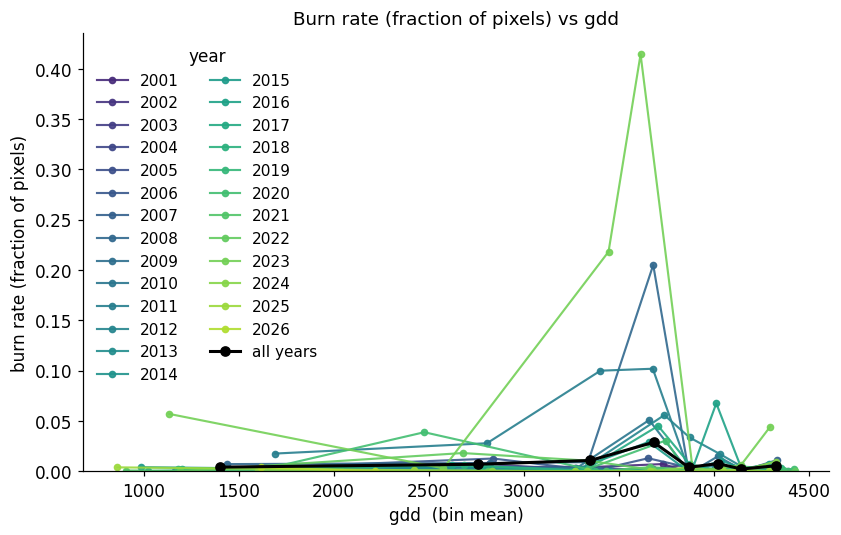

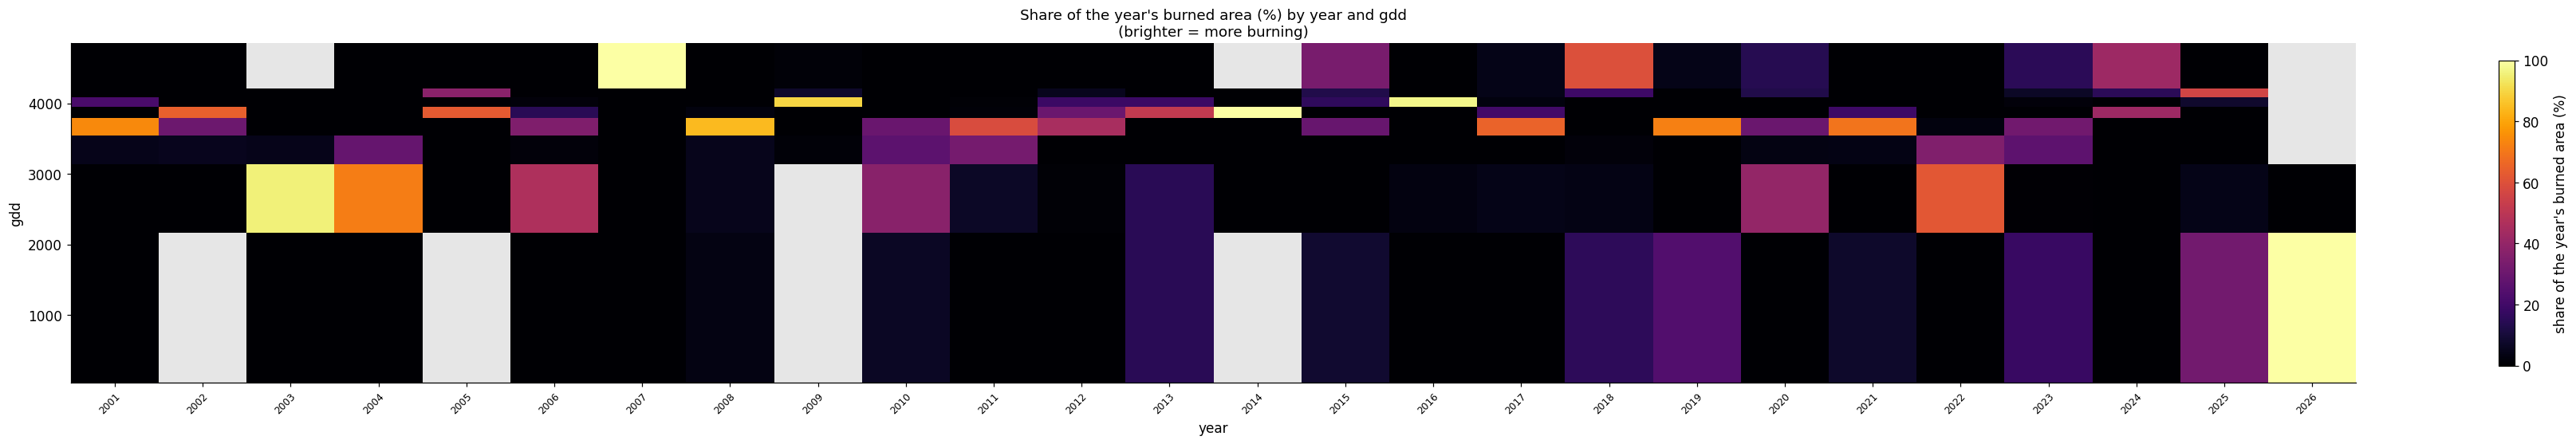

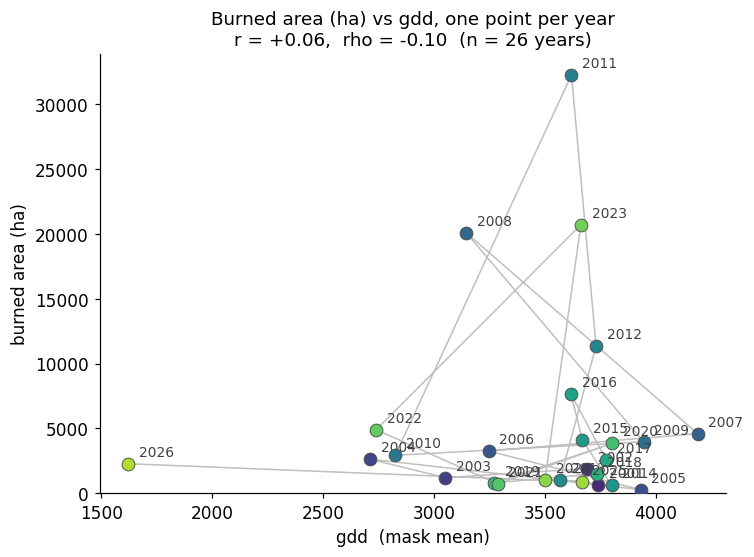

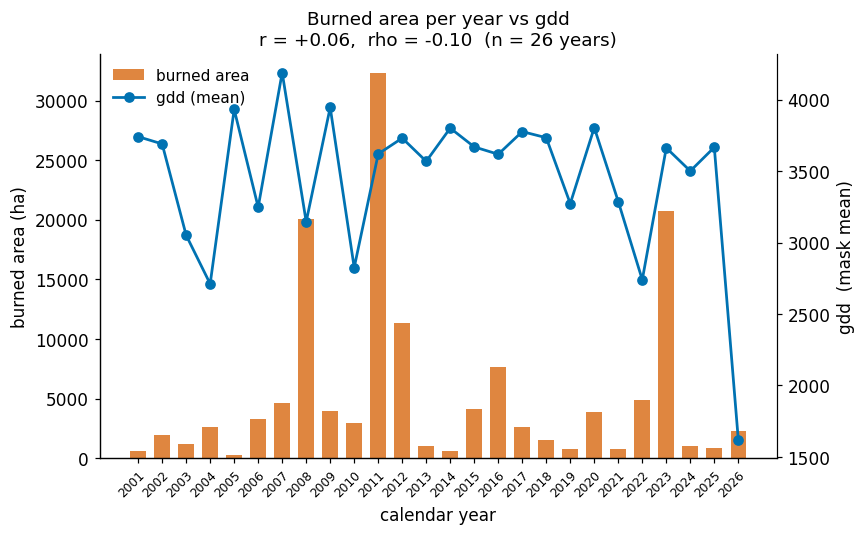

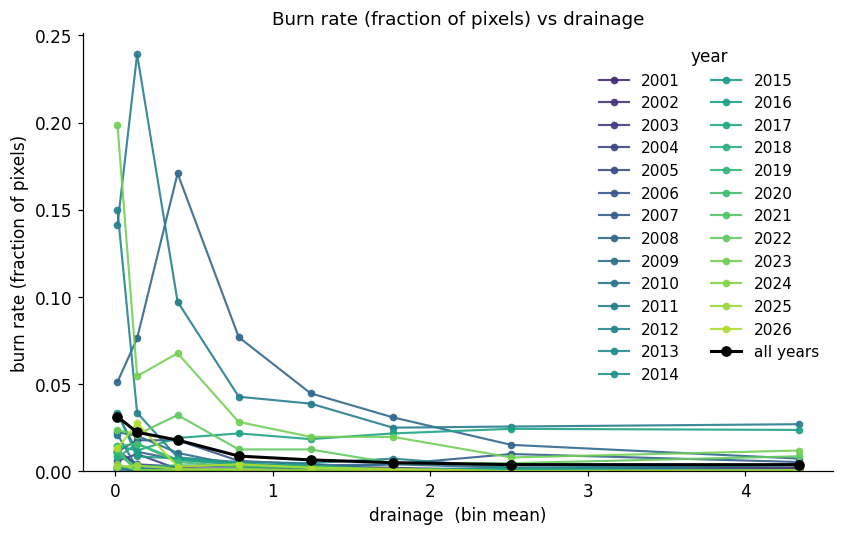

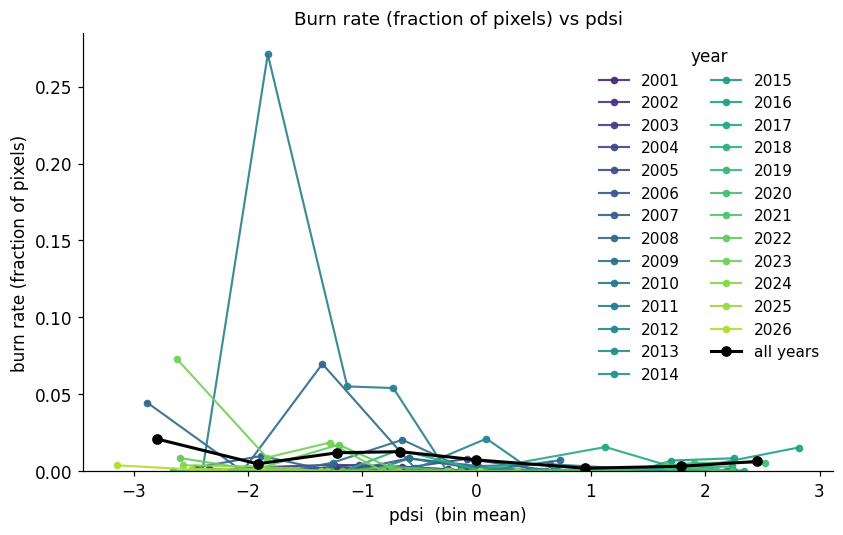

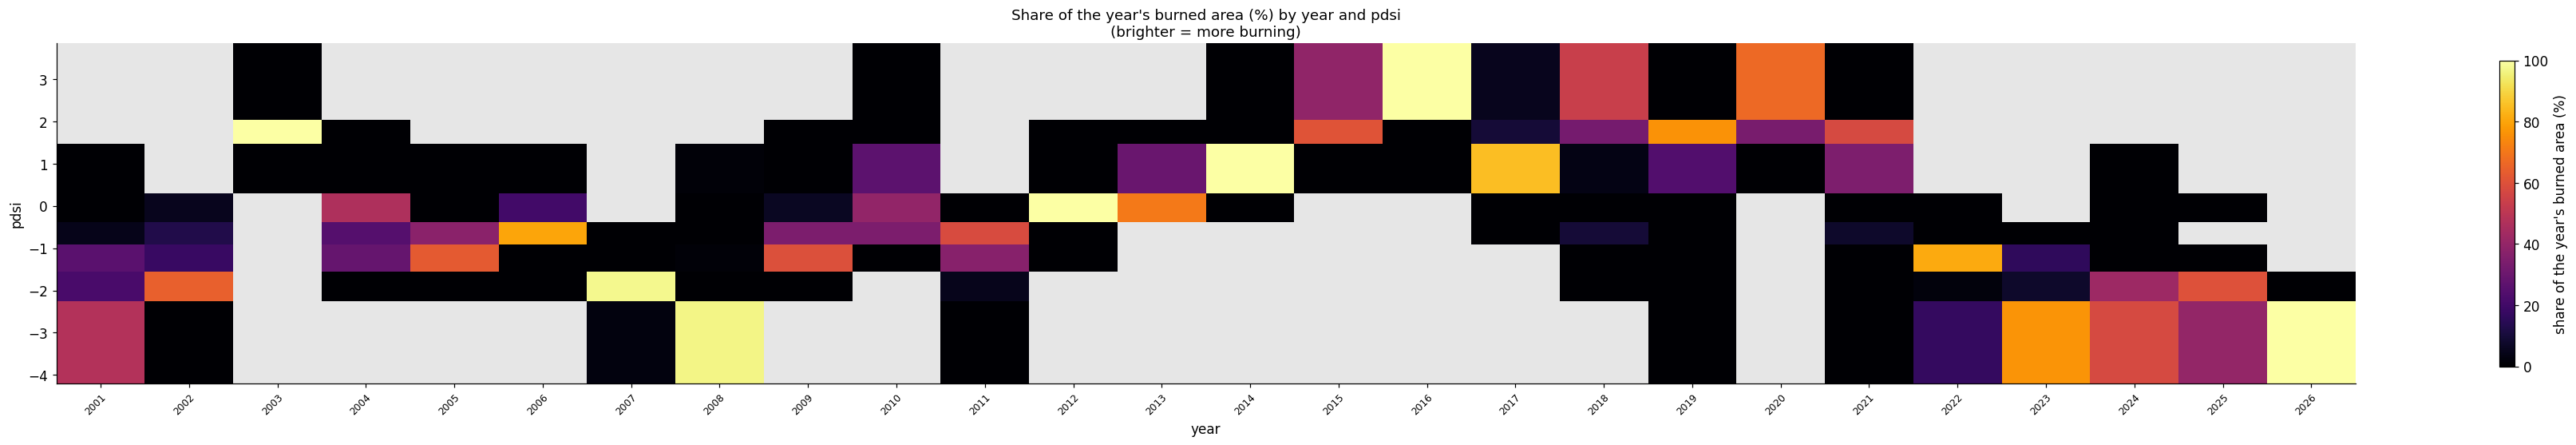

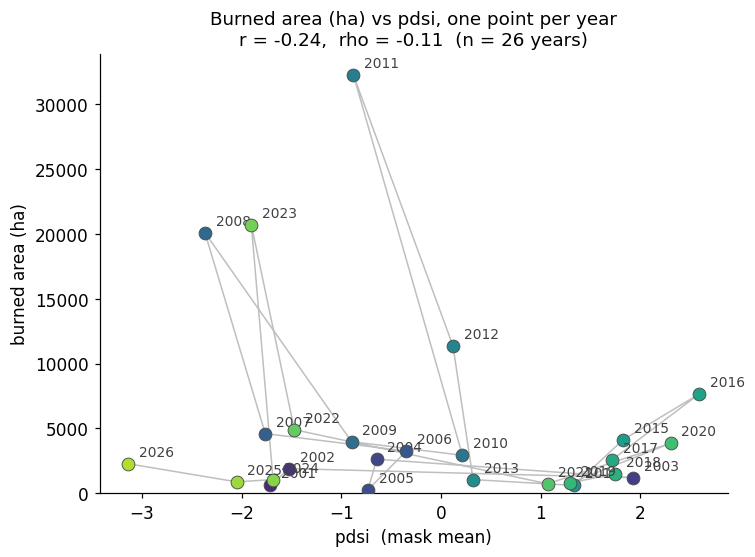

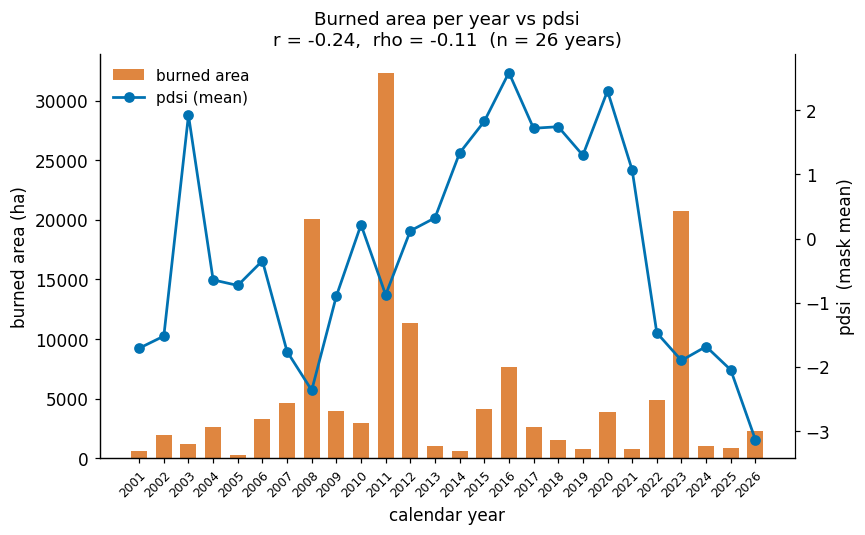

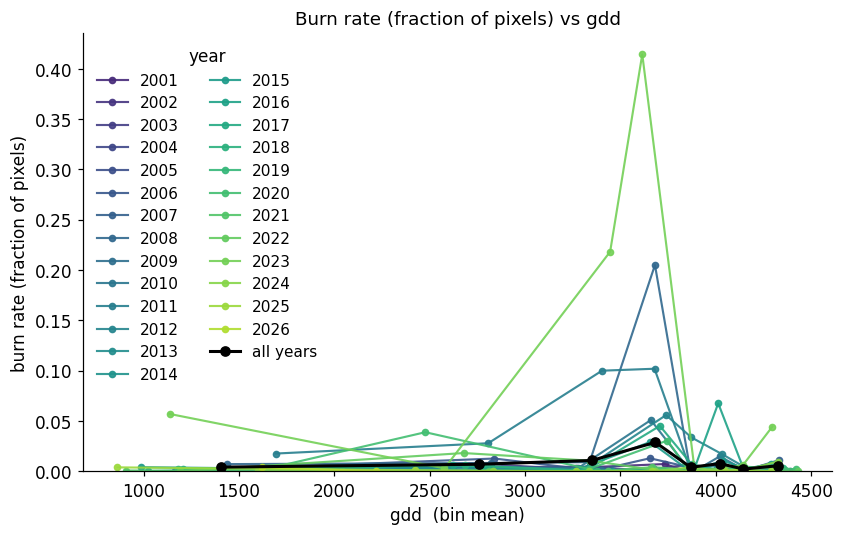

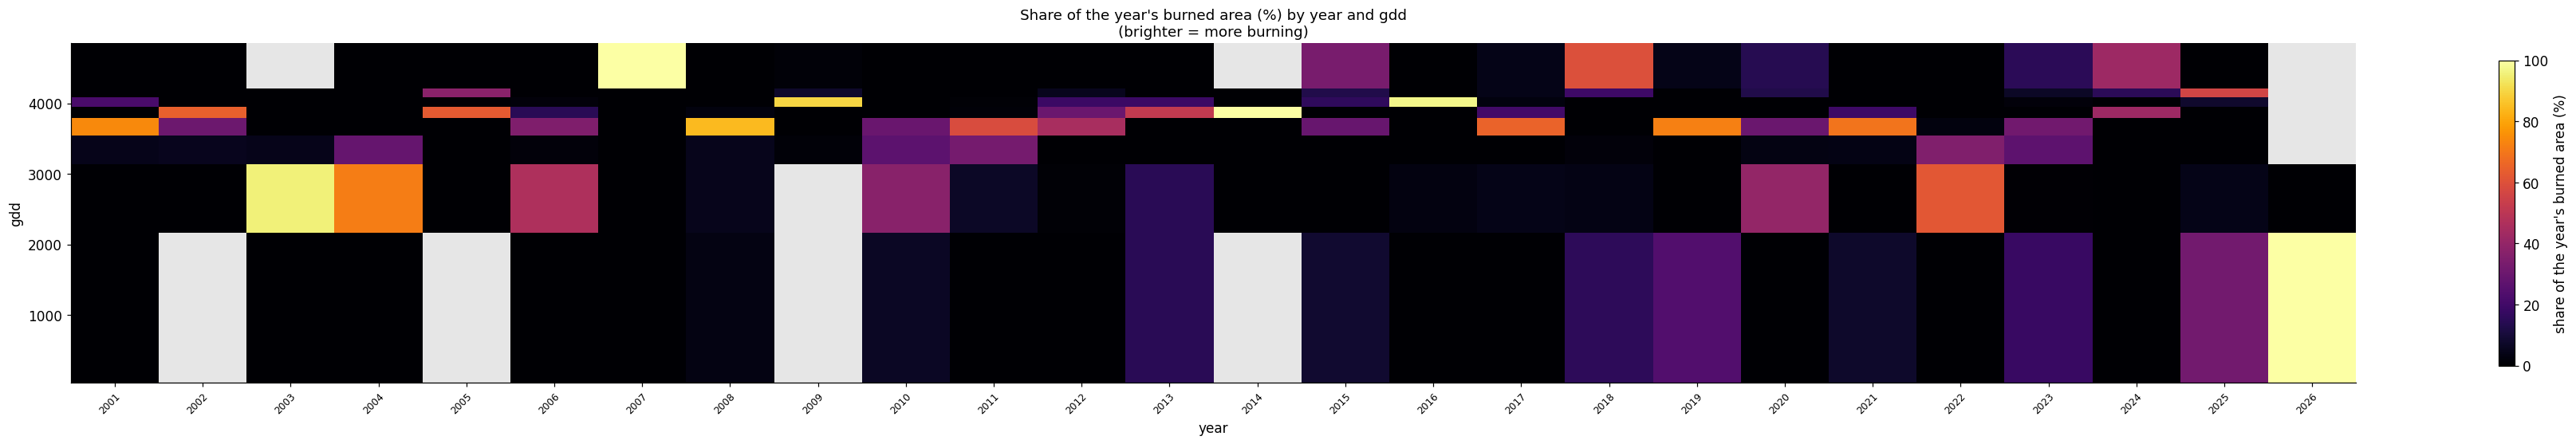

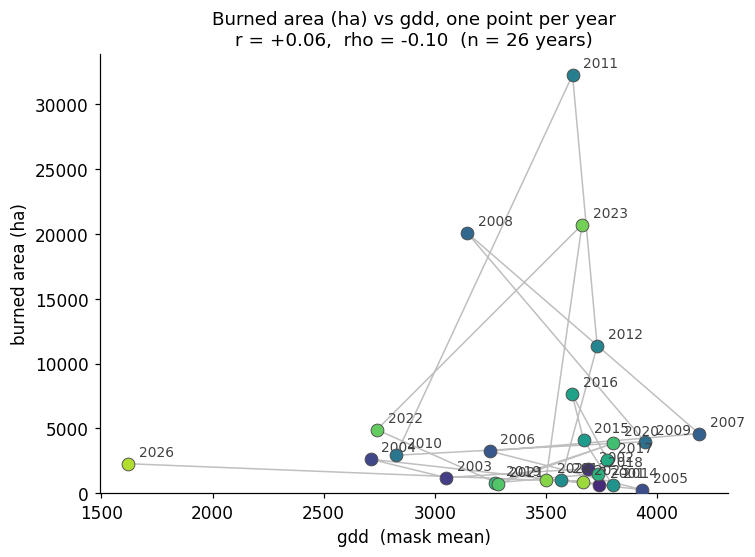

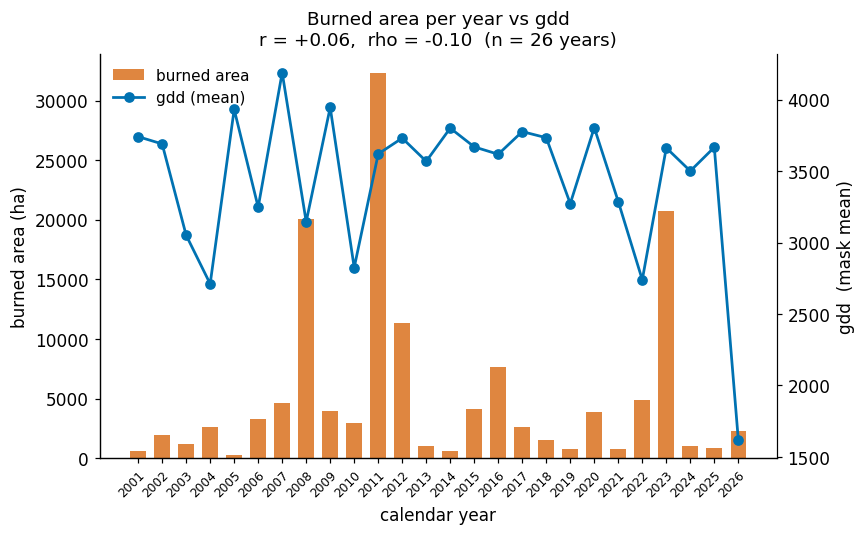

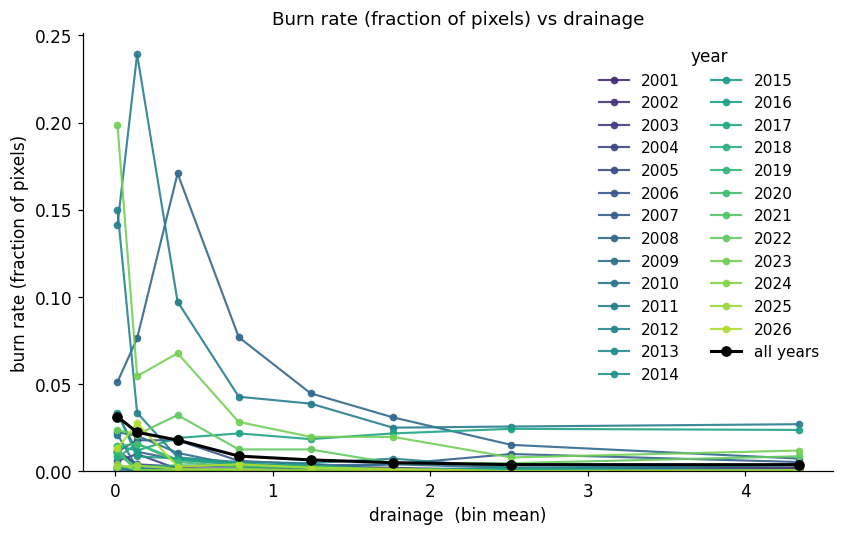

In [11]:
# One table for the whole mask, then every view off it (no re-reading rasters).
# fire_product / YEARS / RES_M come from the cells above.
burned_area_frame = build_mask_frame(
    aoi_nc_peat_80_histosol, product=fire_product, years=YEARS, res_m=RES_M,
)
print("mask pixel-years:", len(burned_area_frame),
      "| burned pixel-years:", int((burned_area_frame["burned"] > 0).sum()),
      "| total burned area (ha):",
      round(float((burned_area_frame["burned"] > 0).mul(
          burned_area_frame["pixel_area_ha"]).sum()), 1))
# Sanity check: the ROI is fixed, so every year should carry the same cell count.
print("cells per year:", burned_area_frame.groupby("year").size().to_dict())

# Every continuous covariate in the frame, all four views, saved per covariate as
# <fire_product>_<covariate>_<kind>.png. The two collapsed views are skipped for
# categorical layers and are degenerate (flat / vertical) for static ones.
figs = plot_burned_area_vs_covariates_over_years(
    fire_product=fire_product,
    frame=burned_area_frame,        # prebuilt above; pass mask=... to build it here
    kinds=("vs_covariate", "heatmap", "by_year", "annual"),
    metric="area_ha",               # "rate" divides out bin size, "share" the year
    out_dir=FIG_DIR,
    close=True,                     # sweeping ~10 covariates -> don't hold them open
)
print("saved", len(figs), "figures ->", FIG_DIR)

# The two retained climate drivers up close, one view at a time (each returns the
# Figure, so it displays). Both are PER-YEAR layers, which is what makes the two
# collapsed views (`plot_annual_burned_area_vs_covariate` and
# `plot_burned_area_and_covariate_by_year`) informative here and degenerate for the
# static layers: only a covariate that moves between years can line its own
# year-to-year swings up against the year-to-year burned-area swings.
#   * pdsi -- annual-mean scPDSI, NEGATIVE = drought. Expect the big fire years at
#     the low end.
#   * gdd  -- that year's accumulated growing degree days (base 5 C), higher = a
#     warmer growing season.
for _weather in [c for c in ("pdsi", "gdd") if c in burned_area_frame.columns]:
    display(plot_burned_area_vs_covariate(burned_area_frame, _weather, metric="rate"))
    display(plot_burned_area_covariate_heatmap(burned_area_frame, _weather, metric="share"))
    display(plot_annual_burned_area_vs_covariate(burned_area_frame, _weather))

    fig = plot_burned_area_and_covariate_by_year(burned_area_frame, _weather)
    fig.savefig(FIG_DIR / f"{fire_product}_burned_area_{_weather}_by_year.png",
                bbox_inches="tight")
    display(fig)

# A static layer for contrast: informative binned (it varies across space), blank
# collapsed (it does not vary across time).
if 'drainage' in covariates:
    display(plot_burned_area_vs_covariate(burned_area_frame, "drainage", metric="rate"))


In [12]:
# Doubly-robust group-time ATT with site-clustered standard errors (Callaway & Sant'Anna 2021) via did.fit_att,
# which chains build_panel -> estimate_att -> aggregate_att ("simple" + "event");
# NaN-response rows are dropped inside build_panel. Needs `pip install
# differences`. Wrapped so a missing optional backend / fire coverage doesn't
# abort the rest of the notebook (the levels / odds-ratio route in §3-4 is
# self-contained).
covs = [c for c in covariates if c in panel.columns and c not in excluded_covariates]

event_study = None
try:
    att, overall, event_study = did.fit_att(
        panel, covariates=covs, response="burned",
        cluster_by=cluster_by, cluster_col="site_id", random_state=42,
    )
    print("overall ATT (site-clustered SEs):", overall)   # Castro's headline number
except Exception as e:
    print("staggered DiD skipped (needs `differences` backend + fire coverage):", e)

event_study   # ATT by event time; pre-treatment rows are the parallel-trends check


/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/did.py:1222: UserWarning: 19834 of 21541 pixel(s) (92%) are alone in their 'site_id' cluster, so the multiplier bootstrap draws them independently: only 6 cluster(s) actually group pixels. These standard errors are site-clustered in name but close to pixel-level in fact. This is what an unmatched control pool looks like -- controls belong to no restoration site, so prepare_panel() gives each its own singleton. Run the DiD on the matched panel (restrict_panel_to_matched), where every control inherits its treated partner's site, or read these SEs as the pixel-level ones they effectively are.
  att = estimate_att(
Computing ATTgt [workers=1]   100%|████████████████████| 100/100 [00:03<00:00, 33.10it/s]
Bootstrap                     100%|████████████████████| [00:00<00:00, 21190.63it/s]
Bootstrap                     100%|████████████████████| [00:00<00:00, 4261.65it/s]

overall ATT (site-clustered SEs):   SimpleAggregation                                                         
                    bootstrap simult. conf. band                            
                ATT std_error              lower     upper zero_not_in_cband
0          0.006488  0.000615             0.0053  0.007677                 *


EventAggregation                                         \
                                 bootstrap simult. conf. band             
                             ATT std_error              lower     upper   
relative_period                                                           
-24                    -0.002122  0.001225          -0.005790  0.001546   
-23                     0.001699  0.001049          -0.001442  0.004840   
-22                     0.000132  0.000787          -0.002224  0.002488   
-21                     0.000023  0.000283          -0.000823  0.000870   
-20                    -0.000904  0.000595          -0.002685  0.000877   
-19                     0.000490  0.000606          -0.001324  0.002305   
-18                    -0.005265  0.003048          -0.014389  0.003858   
-17                    -0.002999  0.001359          -0.007068  0.001070   
-16                     0.004924  0.001067           0.001732  0.008117   
-15                    -0.028675  0.002312          -0.035595 -0.021756   
-14                     0.026897  0.002387           0.019751  0.034043   
-13                    -0.027948  0.005800          -0.045310 -0.010585   
-12                     0.043478  0.005563           0.026826  0.060130   
-11                    -0.031981  0.002757          -0.040233 -0.023730   
-10                     0.039446  0.002574           0.031742  0.047149   
-9                     -0.014734  0.001499          -0.019221 -0.010246   
-8                      0.179774  0.002791           0.171419  0.188129   
-7                     -0.191885  0.002697          -0.199960 -0.183811   
-6                     -0.001148  0.001612          -0.005974  0.003678   
-5                      0.006117  0.001484           0.001676  0.010559   
-4                      0.003106  0.000614           0.001268  0.004944   
-3                     -0.021127  0.002237          -0.027822 -0.014431   
-2                      0.023284  0.002999           0.014307  0.032262   
-1                      0.003620  0.001793          -0.001748  0.008989   
0                       0.004842  0.000347           0.003803  0.005880   
1                      -0.004147  0.001373          -0.008255 -0.000039   
2                      -0.008276  0.001523          -0.012835 -0.003716   
3                       0.046829  0.000892           0.044160  0.049498   
4                       0.010437  0.001801           0.005047  0.015828   
5                      -0.011474  0.000489          -0.012937 -0.010011   
6                      -0.014649  0.000880          -0.017283 -0.012014   
7                       0.026112  0.001431           0.021829  0.030394   

                                   
                                   
                zero_not_in_cband  
relative_period                    
-24                                
-23                                
-22                                
-21                                
-20                                
-19                                
-18                                
-17                                
-16                             *  
-15                             *  
-14                             *  
-13                             *  
-12                             *  
-11                             *  
-10                             *  
-9                              *  
-8                              *  
-7                              *  
-6                                 
-5                              *  
-4                              *  
-3                              *  
-2                              *  
-1                                 
0                               *  
1                               *  
2                               *  
3                               *  
4                               *  
5                               *  
6                               *  
7                               *

### Event study: burning vs time since restoration

`plot_event_study` renders the temporal picture the covariate diagnostics can't:
the staggered-DiD ATT by **event time** (years since each site's restoration),
straight from `did.aggregate_att(att, kind="event")`. Event time 0 is the
restoration year; the **pre-treatment points (shaded, left of the onset line) are
the parallel-trends check** -- they should straddle zero, i.e. treated and control
were on the same burning trajectory *before* the canal blocks went in -- and the
post-treatment points trace how the restoration effect on burning evolves after.


saved /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/outputs/figures/modeling/MCD64A1_site_level_did_event_study_tidy.png


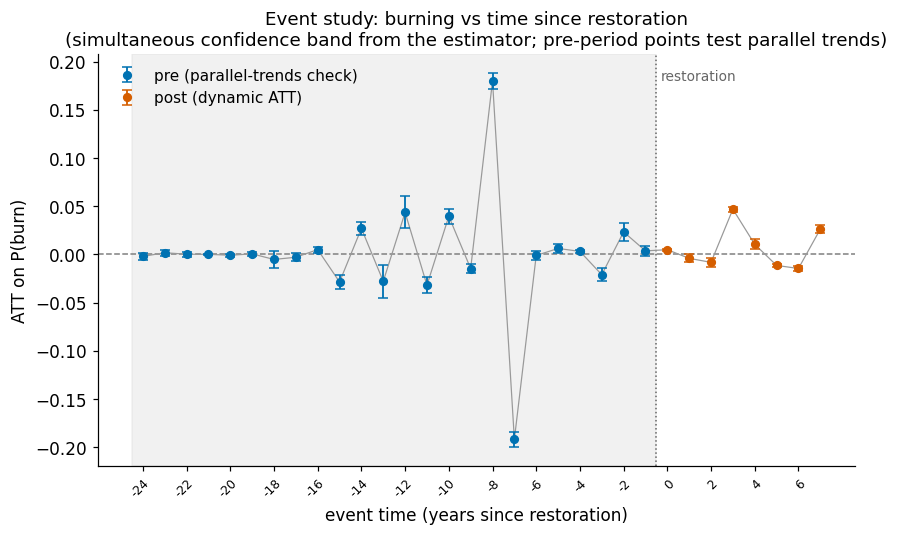

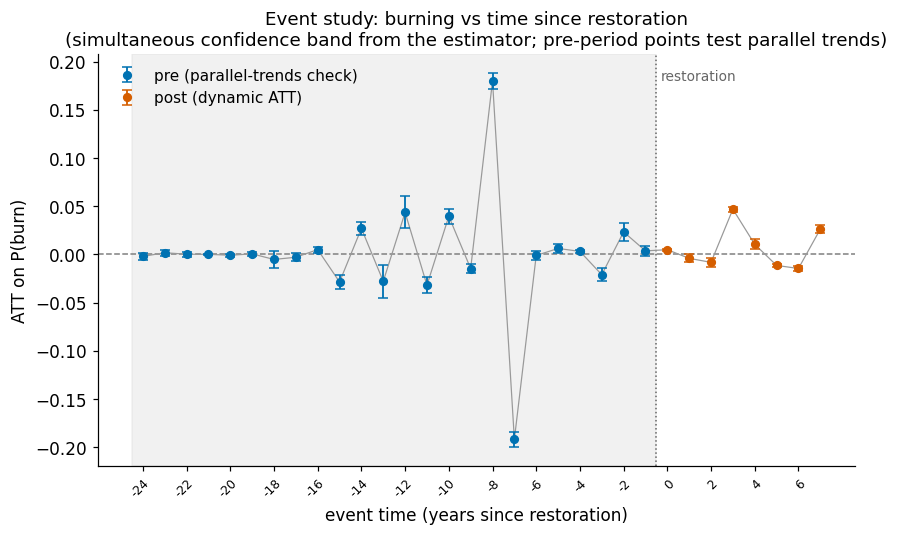

In [13]:
# Temporal diagnostic for the DiD: ATT vs time since restoration, with the
# pre-period points as the parallel-trends check. Consumes the `event_study`
# frame from aggregate_att(..., kind="event") above; skipped if the DiD didn't run.
if event_study is not None:
    fig = plot_event_study(event_study, ylabel="ATT on P(burn)")
    fig.savefig(FIG_DIR / f"{fire_product}_did_event_study_tidy.png", bbox_inches="tight")
    print("saved", FIG_DIR / f"{fire_product}_{cluster_by}_level_did_event_study_tidy.png")
    display(fig)
else:
    print("event study skipped (no DiD result to plot -- see the cell above).")


### Raw burned rate: the unadjusted signal

Before any matching or DiD adjustment, the plainest look at the outcome — the
observed burn rate for treated (restoration) vs control pixels.
`plot_raw_burn_rate_by_year` splits it by **calendar year** (the shared dry /
El Niño swings show up in both groups); `plot_raw_burn_rate_by_event_time`
re-aligns it to **years since each site's restoration** (event time 0 = the
restoration year) — the model-free companion to the DiD event study above. On
the pixel panel the control pool has no restoration year, so it is drawn as a
flat pooled-mean reference; on a matched set (where each control inherits its
site's cohort) both groups get an aligned event-time curve.

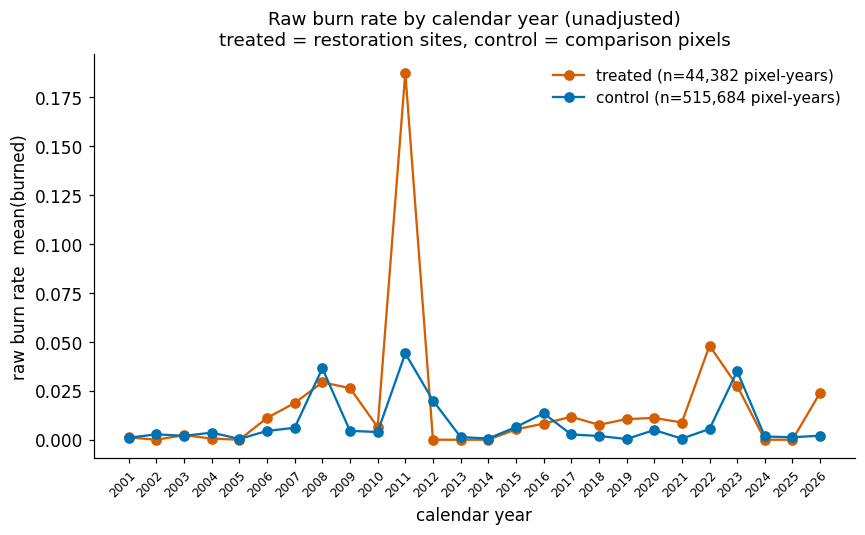

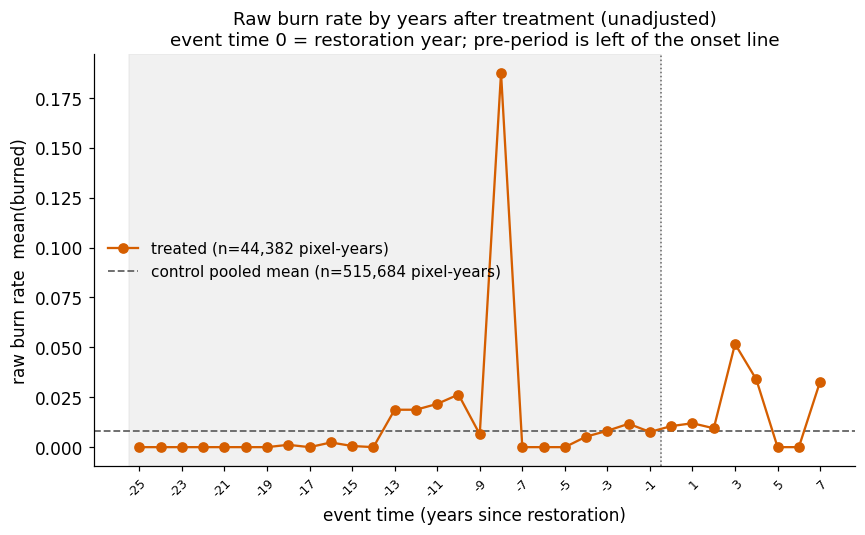

saved raw_burn_rate_by_year.png, raw_burn_rate_by_event_time.png -> /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/outputs/figures/modeling


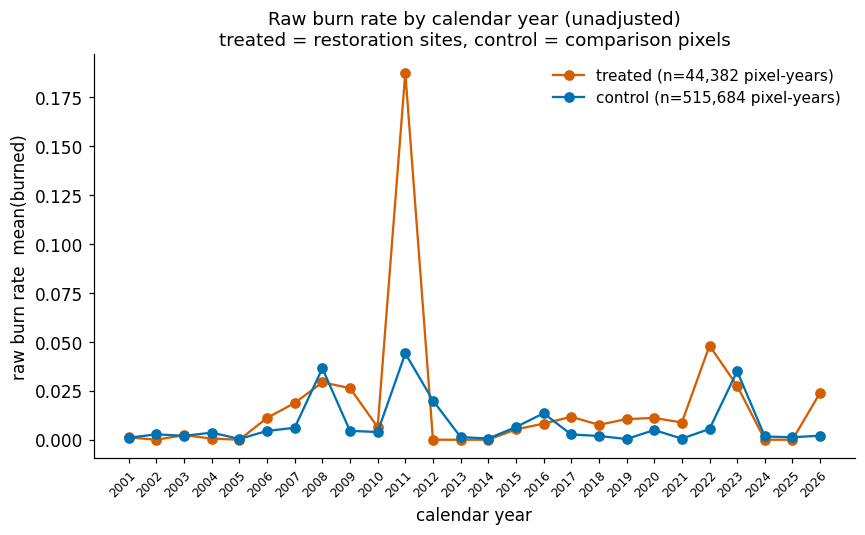

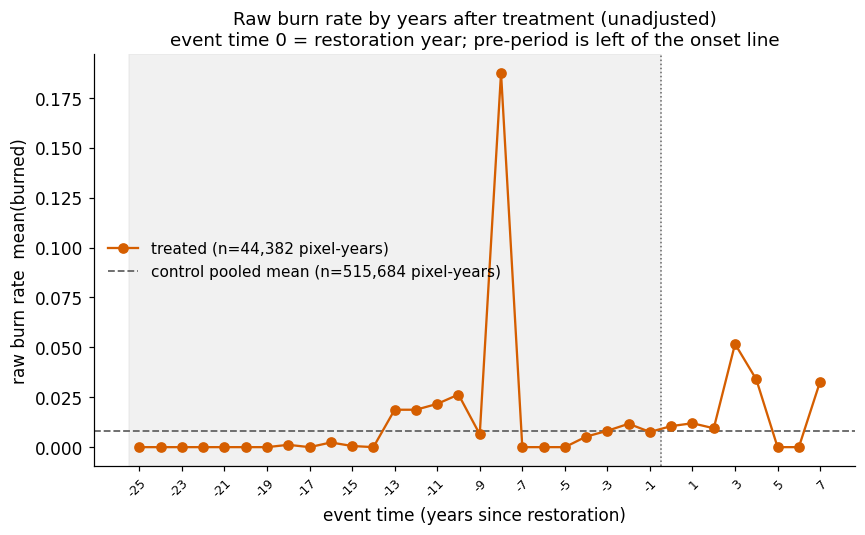

In [14]:
# Raw, unadjusted burn rate straight off the pixel-year `panel` (from §2b) — the
# descriptive signal the DiD / logit are built to explain, before any adjustment.
fig = plot_raw_burn_rate_by_year(panel, restoration_yr_col=restoration_yr_col)
fig.savefig(FIG_DIR / f"{fire_product}_raw_burn_rate_by_year.png", bbox_inches="tight")
display(fig)

fig = plot_raw_burn_rate_by_event_time(panel, restoration_yr_col=restoration_yr_col)
fig.savefig(FIG_DIR / f"{fire_product}_raw_burn_rate_by_event_time.png", bbox_inches="tight")
display(fig)
print("saved raw_burn_rate_by_year.png, raw_burn_rate_by_event_time.png ->", FIG_DIR)

### Match controls + balance (Stage 5-7) → `units`

pair every treated (restoration) pixel with the
nearest control pixel on the covariates, then prove it worked.

1. **`match_controls`** — whiten the covariates (so plain Euclidean distance =
   Mahalanobis) and nearest-neighbour match each treated pixel to a control
   within a caliper. Exact-match categoricals (land cover) once they download.
2. **`balance_table` + `plot_balance`** — the standardized mean difference (SMD)
   per covariate, *before* vs *after* matching. Before, the groups are offset;
   after, `|SMD|` should collapse below 0.1. That overlap is what later lets us
   attribute a fire difference to restoration rather than to geography. The love
   plot is saved to `outputs/figures/modeling/balance_love.png`.
3. **`assemble_units`** — shape the matched pixels into the `units` GeoDataFrame
   (`unit_id`, `site_id`, `treated`, `geometry`) that `build_frame` consumes in §3.

[match] 1189 treated matched to 1189 controls (k=1, caliper=1.0, replace=False, max_dist_m=None); dropped 118 treated pixels (0 with no control within max_dist_m, 118 with none inside the covariate caliper)
[Stage 5 OK] 1,189 treated matched to 1,189 controls; max distance 1 <= caliper 1.
[Stage 6 OK] post-match max |SMD| = 0.057 <= 0.1.
                     smd_before  smd_after
elevation             -0.326335   0.032612
histosol_pct           0.404858  -0.005238
gdd_normal            -0.403448  -0.056707
soil_organic_matter    0.426420   0.000390
soil_awc               0.226166   0.000259
soil_site_index       -0.000046   0.000499
drainage               0.085880  -0.002104
site clusters (effective N): 6
saved /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/outputs/figures/modeling/balance_love.png
units by treatment:
 treated
1    1189
0    1189
Name: count, dtype: int64


,unit_id,site_id,treated,geometry,x,y,elevation,histosol_pct,gdd_normal,soil_organic_matter,soil_awc,soil_site_index,drainage,soil_drainage_class,land_cover,End_Yr,pair_id,match_distance
0,0,Dare Bombing Range WMP,1,POINT (1795560.262 1599775.871),1.795560e+06,1.599776e+06,3.918629,90.0,3747.129395,24.981268,0.184450,19.767443,2.098124,6.0,7452.0,2019.0,0,0.000000
1,1,Dare Bombing Range WMP,0,POINT (1800560.262 1585775.871),1.800560e+06,1.585776e+06,5.156969,90.0,3794.728760,24.981268,0.184450,19.767443,2.150723,6.0,7452.0,NaN,0,0.335285
2,2,Dare Bombing Range WMP,1,POINT (1784560.262 1598775.871),1.784560e+06,1.598776e+06,8.874610,90.0,3776.403320,24.981268,0.184450,19.767443,3.842039,6.0,7452.0,2019.0,1,0.000000
3,3,Dare Bombing Range WMP,0,POINT (1780560.262 1606775.871),1.780560e+06,1.606776e+06,7.640499,90.0,3739.985840,24.981268,0.184450,19.767443,3.223412,6.0,7452.0,NaN,1,0.510292
4,4,Dare Bombing Range WMP,1,POINT (1784060.262 1598775.871),1.784060e+06,1.598776e+06,5.171485,90.0,3777.919434,53.088314,0.340282,26.253969,1.228235,6.0,7452.0,2019.0,2,0.000000


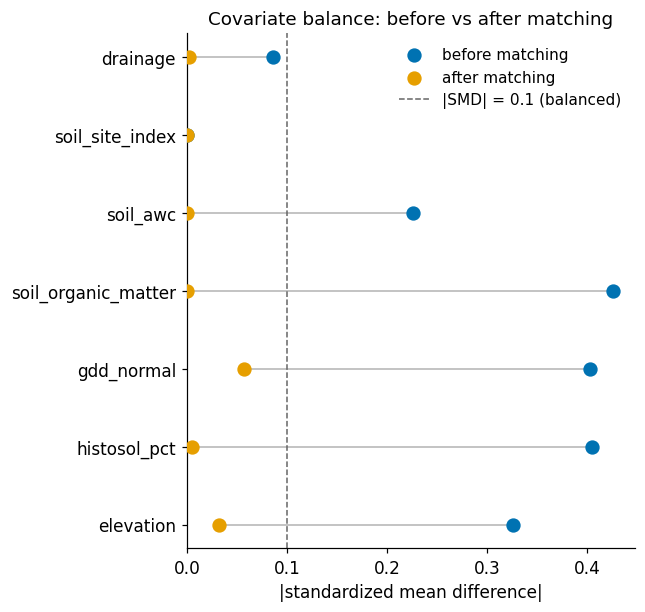

In [15]:
caliper = 1.0   # max match distance, in whitened (Mahalanobis SD) units
k = 1           # 1:1 matching

# --- Stage 6a: balance BEFORE matching -------------------------------------
# On the unmatched panel, balance_table collapses to unique pixels and splits by
# restoration-site membership (treated) vs the candidate pool (control).
before = balance_table(pixels_with_covariates, continuous=covariates,
                       restoration_yr_col=restoration_yr_col)

# --- Stage 5: nearest-neighbour match on the (whitened) covariates ---------
# No categorical layer on disk yet; add categorical=['land_cover'] to exact-match
# once it downloads. replace=False -> each control used at most once. site_id in
# the output is the restoration SITE (Proj_Name): a control inherits its matched
# treated pixel's site, so SEs later cluster on the handful of sites, not pixels.
matched = match_controls(
    pixels_with_covariates,
    continuous=covariates,
    categorical=categorical,   # exact-match within land-cover / drainage class
    caliper=caliper,
    k=k,
    replace=False,
    restoration_yr_col=restoration_yr_col,   # 'End_Yr'
    site_col="Proj_Name",
)

# --- Stage 6b: balance AFTER matching + the checks -------------------------
after = balance_table(matched, continuous=covariates)
check_matches(matched, caliper=caliper)   # every control within the caliper
check_balance(before, after)              # every covariate under |SMD| = 0.1

balance = before.join(after, lsuffix="_before", rsuffix="_after")
print(balance)
print("site clusters (effective N):", matched["site_id"].nunique())

# --- Stage 6c: the love plot (the figure that justifies the design) --------
ax = plot_balance(before, after)
ax.get_figure().savefig(FIG_DIR / "balance_love.png", bbox_inches="tight")
print("saved", FIG_DIR / "balance_love.png")

# --- Stage 7: package the matched pixels into `units` for build_frame ------
units = assemble_units(matched)
print("units by treatment:\n", units["treated"].value_counts())
units.head()

In [16]:
from peatfire.modeling.covariates import available_covariates
print('soil_drainage_class' in available_covariates())        # (1) does the spec find your file?
print('soil_drainage_class' in pixels_with_covariates.columns) # (2) did it actually attach?

True
True


/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:371: UserWarning: management: directory /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/processed/management/seus_forest_mgmt does not exist -- skipping.
  return [name for name, spec in COVARIATES.items() if _covariate_file(spec)]


In [17]:
# save units as gdf so we can inspect it in the fire comparison notebook
controls = units[units["treated"] == 0].copy()

out = data_path("processed", "peat_restoration", "matched_controls", "matched_controls.gpkg")
out.parent.mkdir(parents=True, exist_ok=True)
controls.to_file(out, driver="GPKG")
print("saved", len(controls), "control sites ->", out)

saved 1189 control sites -> /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/processed/peat_restoration/matched_controls/matched_controls.gpkg


### Inspect the matches themselves

Per-pair companion to the love plot. In **covariate space**, short segments =
close covariate twins. In the **geographic** view, long connecting lines flag
controls drawn far from their treated site -- possible spatial confounding
(distant controls may differ in unmeasured ways), the reason for adding
climate/soil and, if needed, an exact-match key.

saved matched-pair diagnostics -> /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/outputs/figures/modeling


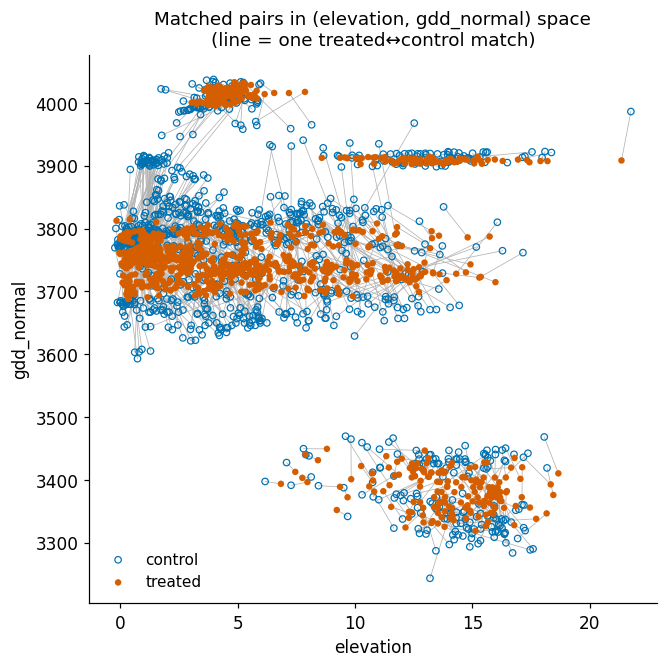

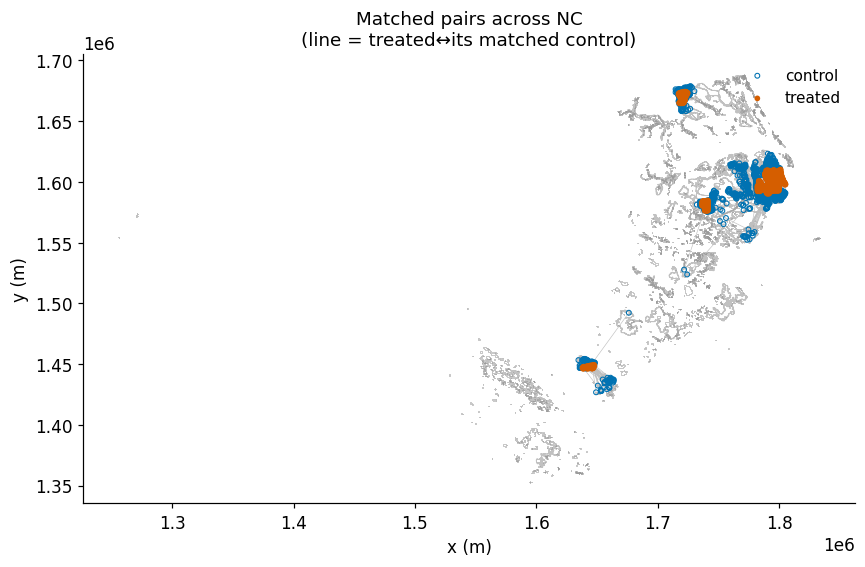

In [18]:
# Prefer two axes with real spread (elevation + a climate/soil covariate) over
# the ~constant histosol for the covariate-space view.
_axes = [c for c in covariates if c != "histosol_pct"] or list(covariates)
_xc = _axes[0]
_yc = _axes[1] if len(_axes) > 1 else "histosol_pct"

fig = plot_matched_pairs_covariate(matched, _xc, _yc)
fig.savefig(FIG_DIR / "matched_pairs_covariate.png", bbox_inches="tight")

fig = plot_matched_pairs_geographic(matched, aoi=aoi_nc_peat_80_histosol)
fig.savefig(FIG_DIR / "matched_pairs_geographic.png", bbox_inches="tight")
print("saved matched-pair diagnostics ->", FIG_DIR)

saved candidate/control pixel map -> /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/outputs/figures/modeling


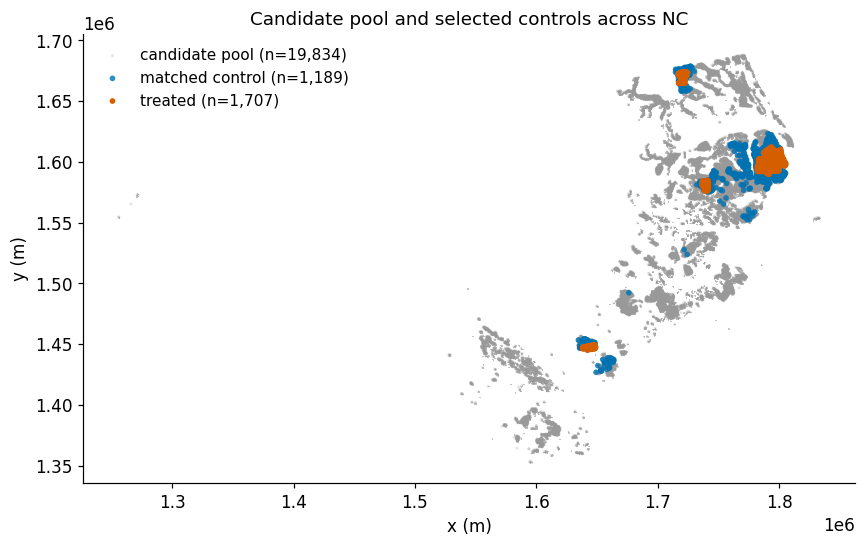

In [19]:
# Candidate pool vs the controls the match actually selected, over NC. The grey
# backdrop is the full control candidate pool (every peat pixel outside the
# treated + spillover halo); the blue points are the subset chosen as matched
# controls, and orange the treated restoration pixels. Tells you whether the
# match drew controls from across the frame or clustered them near the sites.
fig = plot_candidate_control_pixels(
    pixels_with_covariates, matched=matched, aoi=aoi_nc_peat_80_histosol,
    restoration_yr_col=restoration_yr_col,
)
fig.savefig(FIG_DIR / "candidate_control_pixels.png", bbox_inches="tight")
print("saved candidate/control pixel map ->", FIG_DIR)

## 2c. Faithful Castro (2026) matching: per-year prognostic + per-vintage propensity + event-time trajectory

The match in §2 pairs pixels on a single collapsed covariate/score vector. Castro
et al. instead match on a **time series of predicted risk**. This section builds that:

* **per-year prognostic** fire-risk models (`add_prognostic_score_series`) → `phat_<year>`,
  each fit on *never-treated* controls only — so the scores track how baseline risk
  shifts across dry/El Niño years;
* **per-vintage propensity** models (`add_propensity_score_series`) → `psm_<g>`, one per
  restoration cohort, projected onto every pixel;
* an **event-time 1:1 Mahalanobis match** (`match_controls_event_time`) on the trajectory
  vector — pre-construction fire lags + `phat_<t>` for t≥g + `psm_<g>` — per vintage, no
  replacement, **exact-matched on land cover** (no `site_id` exact-match; we cluster SEs on
  site later);
* then **match-first DiD** (`restrict_panel_to_matched`) so the ATT runs on the matched
  controls only.

Diagnostic plots at each step: the per-year risk trajectory, score common-support, the
score maps with matched-pair lines, and the matched-DiD event study.

In [20]:
# Faithful Castro match inputs, in place of the single collapsed score. `panel` (from 2b)
# already carries burned, End_Yr, year and the continuous covariates; attach the
# categorical land-cover layer too (for exact-matching) if it is on disk.
scored = panel.copy()
if not isinstance(scored, gpd.GeoDataFrame) or scored.geometry.isna().all():
    scored = gpd.GeoDataFrame(
        scored, geometry=gpd.points_from_xy(scored["x"], scored["y"]), crs="EPSG:5070"
    )

# ensure the exact-match categorical(s) are sampled onto the panel; fall back cleanly
_missing_cat = [c for c in categorical if c not in scored.columns]
if _missing_cat:
    try:
        scored = attach_covariates(scored, _missing_cat, aoi_nc_peat_80_histosol, RES_M,
                                   temporal_names=[])
    except Exception as e:
        print("could not attach categorical layer(s)", _missing_cat, "->", e,
              "\n-> proceeding WITHOUT land-cover exact matching")
match_cat = [c for c in categorical if c in scored.columns]
print("exact-match keys in use:", match_cat or "(none on disk)")

# per-YEAR prognostic (phat_<year>) and per-VINTAGE propensity (psm_<g>)
scored = add_prognostic_score_series(scored, continuous=covariates, categorical=match_cat,
                                     response="burned", restoration_yr_col=restoration_yr_col)
scored = add_propensity_score_series(scored, continuous=covariates, categorical=match_cat,
                                     restoration_yr_col=restoration_yr_col)

phat_cols = sorted((c for c in scored.columns if c.startswith("phat_") and c[5:].isdigit()),
                   key=lambda c: int(c[5:]))
psm_cols  = sorted((c for c in scored.columns if c.startswith("psm_") and c[4:].isdigit()),
                   key=lambda c: int(c[4:]))
print("per-year prognostic  :", phat_cols)
print("per-vintage propensity:", psm_cols)
scored.drop_duplicates(["x", "y"])[["x", "y", restoration_yr_col, *phat_cols, *psm_cols]].head()


exact-match keys in use: ['soil_drainage_class', 'land_cover']


/var/folders/f0/1x9ky0yd3nj4p68sphk83ngr0000gn/T/ipykernel_69482/3385096803.py:23: UserWarning: prognostic 2019: fell back to the base rate (0); too few never-treated controls or no fire variation that year.
  scored = add_prognostic_score_series(scored, continuous=covariates, categorical=match_cat,


per-year prognostic  : ['phat_2001', 'phat_2002', 'phat_2003', 'phat_2004', 'phat_2005', 'phat_2006', 'phat_2007', 'phat_2008', 'phat_2009', 'phat_2010', 'phat_2011', 'phat_2012', 'phat_2013', 'phat_2014', 'phat_2015', 'phat_2016', 'phat_2017', 'phat_2018', 'phat_2019', 'phat_2020', 'phat_2021', 'phat_2022', 'phat_2023', 'phat_2024', 'phat_2025', 'phat_2026']
per-vintage propensity: ['psm_2019', 'psm_2021', 'psm_2023', 'psm_2026']


,x,y,End_Yr,phat_2001,phat_2002,phat_2003,phat_2004,phat_2005,phat_2006,phat_2007,...,phat_2021,phat_2022,phat_2023,phat_2024,phat_2025,phat_2026,psm_2019,psm_2021,psm_2023,psm_2026
0,1.795560e+06,1.599776e+06,2019.0,0.000927,0.00058,0.000017,0.00226,0.000206,0.001479,0.015061,...,0.000341,0.000402,0.000235,0.000973,0.000588,0.000051,0.251212,9.317080e-07,0.005205,0.003755
1,1.789060e+06,1.598776e+06,2019.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.788560e+06,1.598776e+06,2019.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.788060e+06,1.598776e+06,2019.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.787560e+06,1.598776e+06,2019.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


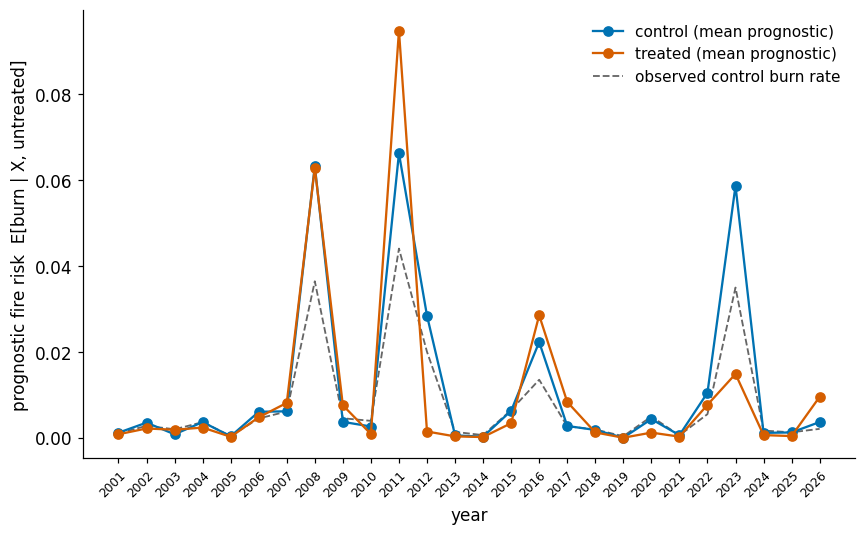

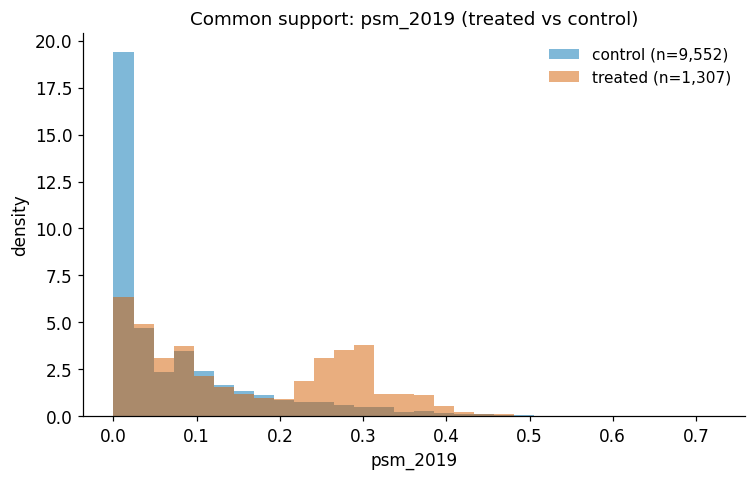

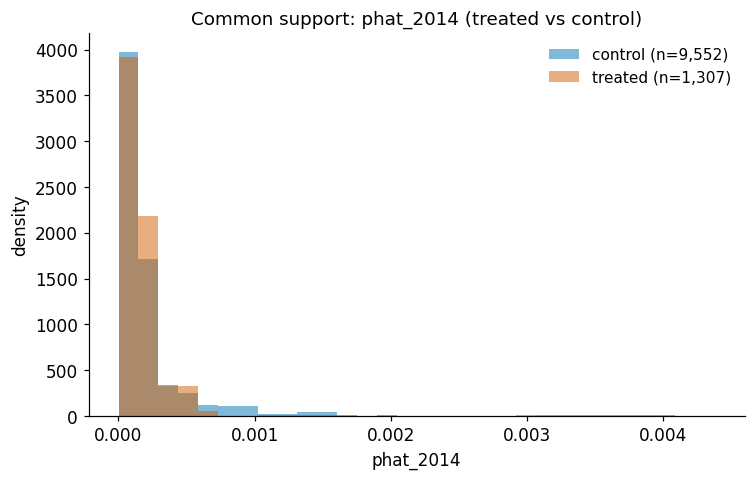

In [21]:
# (i) per-year prognostic risk over time -- the dry-year spikes the per-year model captures
# (single collapsed score cannot). Observed control burn rate overlaid (dashed) as a check.
fig = plot_prognostic_trajectory(scored, response="burned", restoration_yr_col=restoration_yr_col)
fig.savefig(FIG_DIR / f"{fire_product}_prognostic_trajectory.png", bbox_inches="tight")

# (ii) common support: is a score match even feasible? treated vs control score overlap.
# A treated mass where no controls sit (shaded) is where matching drops/stretches.
_ss = scored.copy()
_ss["treated"] = _ss[restoration_yr_col].notna().astype(int)   # static: site membership

_show = (psm_cols[:1] + phat_cols[len(phat_cols) // 2:len(phat_cols) // 2 + 1])
for col in _show:
    fig = plot_score_overlap(_ss, col, restoration_yr_col=restoration_yr_col)
    fig.savefig(FIG_DIR / f"{fire_product}_score_overlap_{col}.png", bbox_inches="tight")

In [22]:
# Event-time 1:1 Mahalanobis match on the trajectory vector (pre-construction fire lags
# + phat_<t> for t>=g + psm_<g>), per vintage, no replacement, EXACT-match on land cover,
# NO site_id exact-match. Out-of-panel components (pre-coverage lags, 2015 under 2019-2024)
# are auto-omitted. `carry` keeps the raw covariates on the output for the balance plot.
matched_et = match_controls_event_time(
    scored, response="burned", categorical=match_cat,
    restoration_yr_col=restoration_yr_col, site_col="Proj_Name",
    pre_lags=(1, 2), drought_year=2015,
    caliper=1.0, k=1, carry=covariates,
)
before_et = balance_table(scored, continuous=covariates, restoration_yr_col=restoration_yr_col)
after_et  = balance_table(matched_et, continuous=covariates)
print("event-time match |SMD| before -> after:")
print(before_et.join(after_et, lsuffix="_before", rsuffix="_after"))
print("site clusters (effective N):", matched_et["site_id"].nunique(),
      "| matched pairs:", matched_et["pair_id"].nunique(),
      "| cohorts:", sorted(matched_et["cohort"].unique()))

[match] 874 treated matched to 874 controls (k=1, caliper=1.0, replace=False, max_dist_m=None); dropped 37 treated pixels (0 with no control within max_dist_m, 37 with none inside the covariate caliper)
[match] 98 treated matched to 98 controls (k=1, caliper=1.0, replace=False, max_dist_m=None); dropped 41 treated pixels (0 with no control within max_dist_m, 41 with none inside the covariate caliper)
[match] 171 treated matched to 171 controls (k=1, caliper=1.0, replace=False, max_dist_m=None); dropped 0 treated pixels (0 with no control within max_dist_m, 0 with none inside the covariate caliper)
[match] 84 treated matched to 84 controls (k=1, caliper=1.0, replace=False, max_dist_m=None); dropped 2 treated pixels (0 with no control within max_dist_m, 2 with none inside the covariate caliper)
event-time match |SMD| before -> after:
                     smd_before  smd_after
elevation             -0.482963  -0.071182
histosol_pct           0.509562   0.042277
gdd_normal            -0.37

saved score maps + pair diagnostics -> /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/outputs/figures/modeling


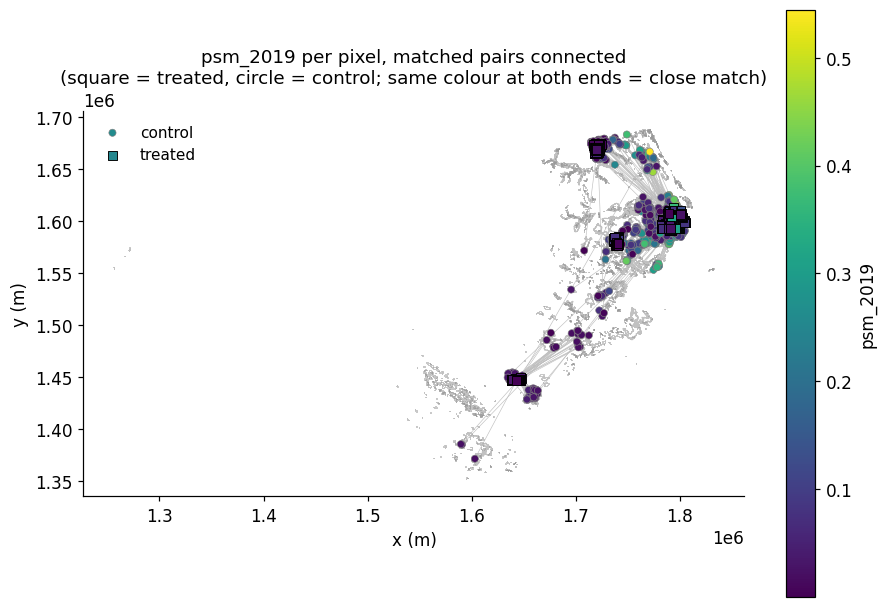

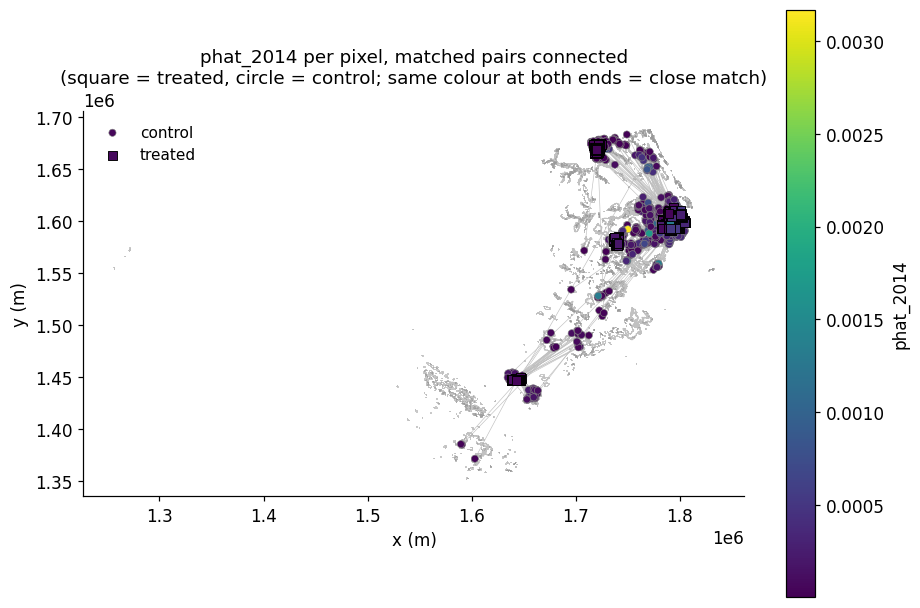

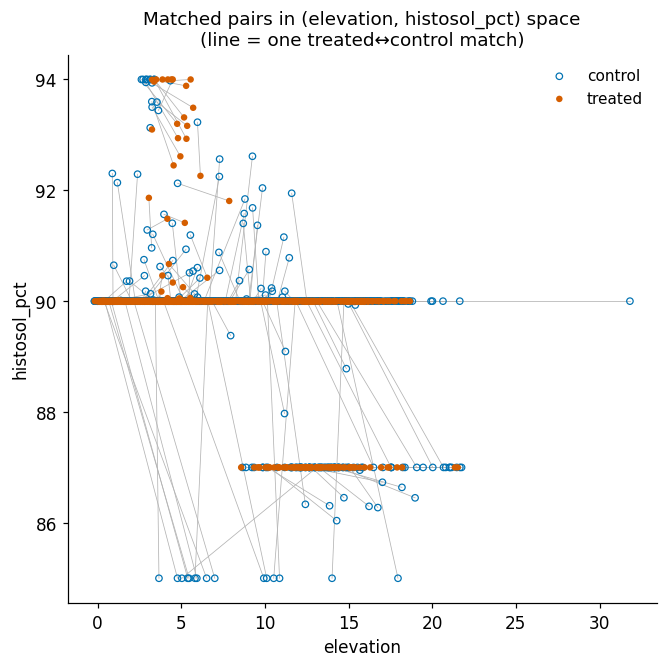

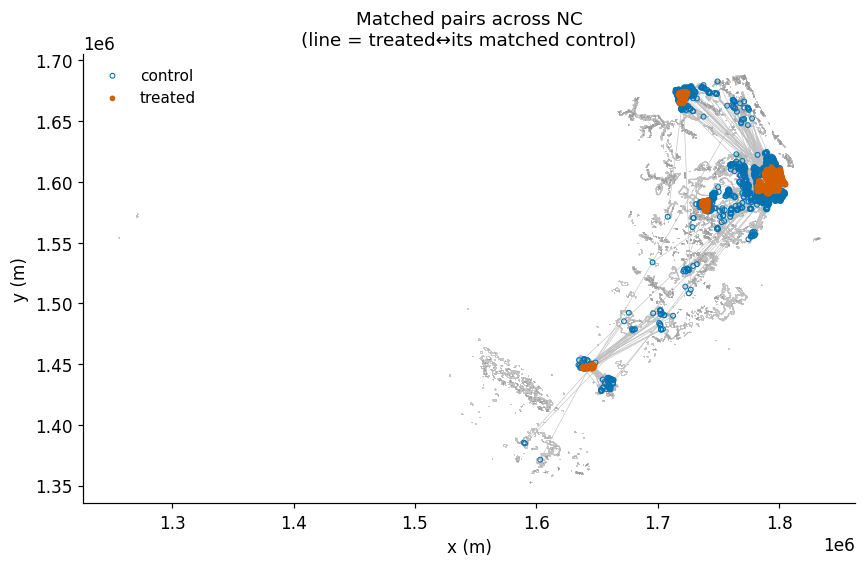

In [23]:
# The requested picture: propensity / prognostic score per pixel on the map, each treated
# pixel joined to its matched control. Same colour at both ends of a line = close score
# match. Scores are looked up from `scored` (the event-time match output carries pixel ids,
# not the ragged per-cohort score columns).
_g0 = psm_cols[0] if psm_cols else None          # a vintage propensity, e.g. psm_2020
_py = phat_cols[len(phat_cols)//2] if phat_cols else None   # a mid-window prognostic year
for col in [c for c in (_g0, _py) if c]:
    fig = plot_score_map(matched_et, col, scores=scored, aoi=aoi_nc_peat_80_histosol)
    fig.savefig(FIG_DIR / f"{fire_product}_score_map_{col}.png", bbox_inches="tight")

# raw-covariate pair diagnostics reuse the existing plots (matched_et carries the covariates)
_x = covariates[0]
_y = covariates[1] if len(covariates) > 1 else covariates[0]
fig = plot_matched_pairs_covariate(matched_et, _x, _y)
fig.savefig(FIG_DIR / "et_pairs_covariate.png", bbox_inches="tight")
fig = plot_matched_pairs_geographic(matched_et, aoi=aoi_nc_peat_80_histosol)
fig.savefig(FIG_DIR / "et_pairs_geographic.png", bbox_inches="tight")
print("saved score maps + pair diagnostics ->", FIG_DIR)

matched panel support (non-null outcomes):


/var/folders/f0/1x9ky0yd3nj4p68sphk83ngr0000gn/T/ipykernel_69482/22229030.py:11: UserWarning: 3 matched pixel(s) appear under more than one treated partner (matching with replacement); keeping the first site_id/pair_id for each in the DiD panel.
  restrict_panel_to_matched(scored, matched_et),


,g,first_outcome_year,last_outcome_year,entities,pre_entities,post_entities,spanning_entities,outcome_rows
0,0,2001,2026,1224,1224,1224,1224,31824
1,2019,2001,2026,874,874,874,874,22724
2,2021,2001,2026,98,98,98,98,2548
3,2023,2001,2026,171,171,171,171,4446
4,2026,2001,2026,84,84,84,84,2184


/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/did.py:1222: UserWarning: clustering SEs on 'site_id' with only 6 cluster(s). Cluster-robust inference is asymptotic in the number of clusters (rule of thumb: 30+), so these SEs are still optimistic and their normal-approximation p-values are anti-conservative. They are nonetheless far more honest than pixel-level SEs; corroborate with att_collapsed() (t with G-1 df) and the event study.
  att = estimate_att(
Computing ATTgt [workers=1]   100%|████████████████████| 100/100 [00:00<00:00, 149.43it/s]
Bootstrap                     100%|████████████████████| [00:00<00:00, 95758.18it/s]
Bootstrap                     100%|████████████████████| [00:00<00:00, 95121.88it/s]
/Users/jinjiang-macair/anaconda3/envs/peat_fire_stanback/lib/python3.11/site-packages/differences/models/attgt/mboot.py:153: RuntimeWarning: invalid value encountered in divide
  b_t = np.max(np.abs(mb_res / 

matched-DiD overall ATT (site-clustered SEs):   SimpleAggregation                                                         
                    bootstrap simult. conf. band                            
                ATT std_error              lower     upper zero_not_in_cband
0          0.006938  0.009251           -0.00745  0.021326                  
saved did_event_study_matched.png


EventAggregation                                     \
                                 bootstrap simult. conf. band         
                             ATT std_error              lower upper   
relative_period                                                       
-24                     0.000000       NaN                NaN   NaN   
-23                    -0.001891  0.003289                NaN   NaN   
-22                     0.003096  0.003995                NaN   NaN   
-21                    -0.000397  0.001382                NaN   NaN   
-20                    -0.000813  0.002776                NaN   NaN   
-19                     0.001866  0.007042                NaN   NaN   
-18                    -0.004821  0.018840                NaN   NaN   
-17                     0.000579  0.003264                NaN   NaN   
-16                    -0.004056  0.007845                NaN   NaN   
-15                    -0.023129  0.054792                NaN   NaN   
-14                     0.027540  0.053261                NaN   NaN   
-13                    -0.023432  0.084563                NaN   NaN   
-12                     0.018736  0.075739                NaN   NaN   
-11                    -0.009250  0.033260                NaN   NaN   
-10                     0.029088  0.039328                NaN   NaN   
-9                     -0.010261  0.002041                NaN   NaN   
-8                      0.087983  0.069610                NaN   NaN   
-7                     -0.093900  0.067089                NaN   NaN   
-6                      0.000332  0.001426                NaN   NaN   
-5                      0.000024  0.002187                NaN   NaN   
-4                     -0.000826  0.004864                NaN   NaN   
-3                     -0.063658  0.029383                NaN   NaN   
-2                      0.062146  0.025586                NaN   NaN   
-1                      0.002994  0.005735                NaN   NaN   
0                       0.006690  0.004744                NaN   NaN   
1                      -0.001330  0.025155                NaN   NaN   
2                       0.000501  0.017557                NaN   NaN   
3                       0.038827  0.025685                NaN   NaN   
4                       0.001386  0.017643                NaN   NaN   
5                       0.000292  0.000770                NaN   NaN   
6                       0.000000       NaN                NaN   NaN   
7                       0.005320  0.007075                NaN   NaN   

                                   
                                   
                zero_not_in_cband  
relative_period                    
-24                                
-23                                
-22                                
-21                                
-20                                
-19                                
-18                                
-17                                
-16                                
-15                                
-14                                
-13                                
-12                                
-11                                
-10                                
-9                                 
-8                                 
-7                                 
-6                                 
-5                                 
-4                                 
-3                                 
-2                                 
-1                                 
0                                  
1                                  
2                                  
3                                  
4                                  
5                                  
6                                  
7

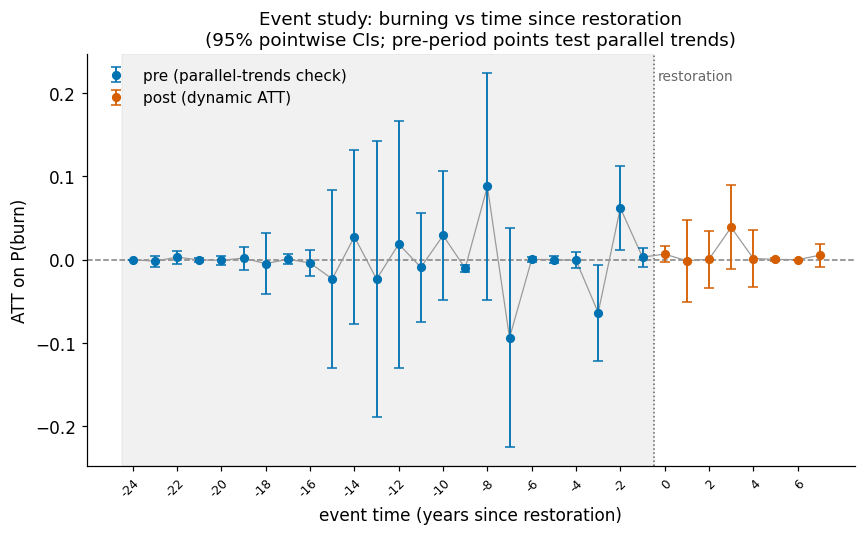

In [24]:
# Match first, THEN DiD: restrict the panel to the matched pixels, rebuild the
# unit_id / cohort bookkeeping on the survivors (did.prepare_panel), and run the
# same Callaway-Sant'Anna ATT (did.fit_att) with site-clustered standard
# errors -- now identified against each treated pixel's matched control(s) instead
# of the full candidate pool. Report effective outcome support before fitting,
# while retaining the 2b-style guard so a missing backend or fire coverage does
# not abort the notebook.
event_study_matched = None
try:
    panel_m = did.prepare_panel(
        restrict_panel_to_matched(scored, matched_et),
        restoration_yr_col=restoration_yr_col, site_col="Proj_Name",
    )
    covs_m = [c for c in covariates if c in panel_m.columns and c not in excluded_covariates]
    print("matched panel support (non-null outcomes):")
    display(did.panel_support_table(panel_m, response="burned"))
    att_m, overall_m, event_study_matched = did.fit_att(
        panel_m, covariates=covs_m, response="burned",
        cluster_by=cluster_by, cluster_col="site_id", random_state=42,
    )
    print("matched-DiD overall ATT (site-clustered SEs):", overall_m)
    fig = plot_event_study(event_study_matched)
    fig.savefig(FIG_DIR / f"{fire_product}_{cluster_by}_level_did_event_study_matched.png", bbox_inches="tight")
    print("saved did_event_study_matched.png")
except Exception as e:
    print("matched staggered DiD skipped (needs `differences` backend + fire coverage):", e)
event_study_matched


print did values

In [25]:
b = panel_m.copy()
b["restored"] = (b["g"] > 0).astype(int)
g_by_site = b.loc[b["g"] > 0].groupby("site_id")["g"].min()
b["_g"] = b["site_id"].map(g_by_site)
b["period"] = np.where(b["year"] >= b["_g"], "post", "pre")

tab = (
    b.groupby(["site_id", "period", "restored"])["burned"]
     .agg(pixyr="size", burns="sum")
     .assign(rate=lambda d: d["burns"] / d["pixyr"])
     .reset_index()
)
print(tab.pivot_table(index=["site_id", "period"], columns="restored",
                      values=["burns", "rate"]))

# theta_s = (treated post-pre) - (control post-pre): the per-site DiD, by hand
w = tab.pivot_table(index=["site_id", "restored"], columns="period", values="rate")
theta = (w["post"] - w["pre"]).unstack("restored")
theta["theta_s"] = theta[1] - theta[0]
print(theta)

                                     burns             rate          
restored                                 0      1         0         1
site_id                      period                                  
ARNWR Restoration East       post      9.0    2.0  0.007705  0.001712
                             pre      82.0   38.0  0.031202  0.014460
ARNWR WMP                    post      0.0    0.0  0.000000  0.000000
                             pre      34.0    2.0  0.008745  0.000514
Angola Bay Restoration Area  post      0.0    0.0  0.000000  0.000000
                             pre      58.0    0.0  0.027952  0.000000
Dare Bombing Range WMP       post     24.0  124.0  0.005859  0.030273
                             pre     185.0  357.0  0.020074  0.038737
GDSNWR Pasquotank Headwaters post      0.0    0.0  0.000000  0.000000
                             pre       0.0    0.0  0.000000  0.000000
PLNWR Flood Resilience       post     26.0    0.0  0.044218  0.000000
                    

## 3. Build the tidy pixel-year frame

In [26]:
# Consumes the matched `units` from Stage 7.
# site_id_col='site_id' -> the restoration SITE assemble_units carries through;
# that is what fit_logit_clustered clusters the standard errors on (effective N =
# number of restoration sites, not pixels).
#
# Three things must track the configuration in step 1b rather than build_frame's
# defaults, or this route silently analyses a different dataset from the DiD:
#   * product   -> `fire_product`, the single outcome switch (default is FireCCIS311)
#   * res_m     -> RES_M; `units` are pixel centroids from the RES_M grid, so a
#                  different grid here re-bins them onto cells they never came from
#   * covariates-> the exclusion set, for both the static and per-year layers
#                  (both default to "every layer on disk", exclusions ignored)
covariate_names = [c for c in available_covariates()
                   if c not in excluded_covariates]
frame_temporal_names = [c for c in available_temporal_covariates(YEARS)
                        if c not in excluded_covariates]
print('frame static covariates :', covariate_names)
print('frame per-year covariates:', frame_temporal_names)

frame = build_frame(
    units,
    product=fire_product,                            # not a hardcoded product
    years=YEARS,
    covariate_names=covariate_names,
    temporal_covariate_names=frame_temporal_names,
    res_m=RES_M,                                     # same grid `units` were matched on
    site_id_col='site_id',
)
print(frame.shape)
print("burn rate by treatment:")
print(frame.groupby("treated")["burned"].mean())
frame.head()


frame static covariates : ['elevation', 'histosol_pct', 'gdd_normal', 'soil_organic_matter', 'soil_awc', 'soil_drainage_class', 'soil_site_index', 'land_cover', 'drainage']
frame per-year covariates: ['pdsi', 'gdd']


/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/modeling/covariates.py:371: UserWarning: management: directory /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/processed/management/seus_forest_mgmt does not exist -- skipping.
  return [name for name, spec in COVARIATES.items() if _covariate_file(spec)]


(61750, 18)
burn rate by treatment:
treated
0.0    0.016766
1.0    0.022805
Name: burned, dtype: float32


,unit_id,site_id,treated,y,x,elevation,histosol_pct,gdd_normal,soil_organic_matter,soil_awc,soil_drainage_class,soil_site_index,land_cover,drainage,year,burned,pdsi,gdd
0,2111.0,4.0,0.0,1.678526e+06,1.725310e+06,14.752860,90.0,3323.781250,61.226475,0.224871,6.0,22.875,7501.0,1.315152,2001,0.0,-2.274524,3845.736816
1,1341.0,4.0,0.0,1.678526e+06,1.725810e+06,15.855002,90.0,3317.254639,61.226475,0.224871,6.0,22.875,7452.0,1.432327,2001,0.0,-2.274909,3843.202148
2,1337.0,4.0,0.0,1.678026e+06,1.721810e+06,11.008623,90.0,3368.371826,61.226475,0.224871,6.0,22.875,7452.0,0.656443,2001,0.0,-2.272331,3816.724121
3,1327.0,4.0,0.0,1.678026e+06,1.722810e+06,14.086557,90.0,3354.932861,61.226475,0.224871,6.0,22.875,7452.0,1.874863,2001,0.0,-2.273372,3824.182373
4,1359.0,4.0,0.0,1.678026e+06,1.723310e+06,14.608171,90.0,3348.213135,61.226475,0.224871,6.0,22.875,7452.0,1.913370,2001,0.0,-2.273856,3833.181885


## 4. Fit + odds ratios

In [27]:
# Cluster-robust logistic: honest SEs (clustered on site_id), not one-per-pixel.
# The adjustment set is DERIVED from `covariates` (the same static continuous list
# the match used) rather than hardcoded, so the methods.md 5.4 exclusions actually
# reach this fit: no precip/tmax normals, no soil_water_table_depth. After the
# exclusions this is elevation + gdd_normal + the SSURGO soil layers (organic
# matter as a fuel-load proxy, AWC as a moisture proxy, site index as a
# productivity proxy).
#
# `histosol_pct` is held out deliberately: on the >=80% histosol frame it is
# near-constant, so it contributes a near-collinear column without adding
# information. Everything is selected against `frame.columns`, so a layer that was
# not built in step 1b is skipped instead of erroring.
_logit_drop = {'histosol_pct'}
covs = [c for c in covariates if c in frame.columns and c not in _logit_drop]
print('adjusting for:', covs)
result = fit_logit_clustered(frame, covariates=covs)   # burned ~ treated + covs
print(result.summary())

# The headline: exp(beta) with CIs. treated < 1 => restoration lowers fire odds.
# (or_table feeds the odds-ratio plot in the next cell.)
or_table = odds_ratios(result)
display(or_table)

# --- Weather interactions: does restoration help MORE in drought / warm years? -
# `pdsi` (annual-mean scPDSI; ~0 = normal, NEGATIVE = drought) and `gdd` (that
# year's accumulated growing degree days, base 5 C) are the per-year weather
# columns build_frame joins on (x, y, year). They are the ONLY per-year predictors
# retained -- the treated:precip/tmax/tmin interactions went with the 5.4
# exclusions, since PDSI carries the moisture-deficit signal and GDD the warmth.
# `treated * <weather>` expands to treated + weather + treated:weather; read the
# interaction row:
#   * pdsi -- low = drought, so a POSITIVE coefficient means the protective effect
#     is strongest in dry years (the mechanistically expected sign);
#   * gdd  -- high = a warm growing season, so a NEGATIVE coefficient means the
#     protective effect is strongest in warm years.
# Note the fit already adjusts for `gdd_normal` (the site's long-run warmth, a
# match covariate), so the `gdd` term is read as the *within-site* year-to-year
# deviation from it -- a between/within split, not a duplicate predictor. Fit them
# one at a time rather than both in one model: with a handful of panel years the
# two weather series are themselves correlated across years, and one interaction at
# a time is what the panel can actually identify.
# Runs only if the per-year rasters were built in step 1b.
weather_results = {}
for weather in ('pdsi', 'gdd'):
    if weather not in frame.columns:
        print(f'per-year `{weather}` not in the frame -- build the annual rasters '
              f'(step 1b) to fit the treated:{weather} interaction.')
        continue
    rhs = ' + '.join([f'treated * {weather}', *covs])
    weather_results[weather] = fit_logit_clustered(
        frame, covariates=covs, formula=f'burned ~ {rhs}'
    )
    print(weather_results[weather].summary())
    display(odds_ratios(weather_results[weather]))   # look at the treated:<weather> row


adjusting for: ['elevation', 'gdd_normal', 'soil_organic_matter', 'soil_awc', 'soil_site_index', 'drainage']
                           Logit Regression Results                           
Dep. Variable:                 burned   No. Observations:                61750
Model:                          Logit   Df Residuals:                    61742
Method:                           MLE   Df Model:                            7
Date:                Sat, 12 Sep 2026   Pseudo R-squ.:                  0.1043
Time:                        10:18:41   Log-Likelihood:                -5376.8
converged:                       True   LL-Null:                       -6003.3
Covariance Type:              cluster   LLR p-value:                2.597e-266
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -5.2067      0.621     -8.383      0.000      -6.424      -3

,beta,odds_ratio,or_ci_low,or_ci_high,p_value
Intercept,-5.206660,0.005480,0.001622,0.018512,5.164081e-17
treated,0.392730,1.481018,0.468253,4.684248,5.038288e-01
elevation,-1.797980,0.165633,0.042154,0.650818,1.001965e-02
gdd_normal,0.148961,1.160628,0.756095,1.781599,4.956993e-01
soil_organic_matter,-0.873490,0.417492,0.056555,3.081968,3.917723e-01
soil_awc,0.849171,2.337708,0.322772,16.931071,4.005794e-01
soil_site_index,-0.219582,0.802854,0.297328,2.167891,6.648256e-01
drainage,0.084263,1.087915,0.514315,2.301232,8.255264e-01


                           Logit Regression Results                           
Dep. Variable:                 burned   No. Observations:                61750
Model:                          Logit   Df Residuals:                    61740
Method:                           MLE   Df Model:                            9
Date:                Sat, 12 Sep 2026   Pseudo R-squ.:                  0.1194
Time:                        10:18:42   Log-Likelihood:                -5286.3
converged:                       True   LL-Null:                       -6003.3
Covariance Type:              cluster   LLR p-value:                3.510e-303
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -5.3091      0.512    -10.374      0.000      -6.312      -4.306
treated                 0.4354      0.514      0.846      0.397      -0.573       1.443
pdsi            

,beta,odds_ratio,or_ci_low,or_ci_high,p_value
Intercept,-5.309133,0.004946,0.001814,0.013486,3.246801e-25
treated,0.435364,1.545525,0.563989,4.235275,3.972997e-01
pdsi,-0.464776,0.628276,0.339454,1.162838,1.389612e-01
treated:pdsi,0.108672,1.114797,0.617008,2.014190,7.188004e-01
elevation,-1.798206,0.165596,0.041798,0.656056,1.046560e-02
gdd_normal,0.135324,1.144907,0.740770,1.769528,5.424068e-01
soil_organic_matter,-0.882530,0.413735,0.055144,3.104179,3.907233e-01
soil_awc,0.858364,2.359297,0.320665,17.358537,3.992371e-01
soil_site_index,-0.222793,0.800280,0.294285,2.176287,6.624843e-01
drainage,0.082012,1.085469,0.510332,2.308775,8.313390e-01


                           Logit Regression Results                           
Dep. Variable:                 burned   No. Observations:                61750
Model:                          Logit   Df Residuals:                    61740
Method:                           MLE   Df Model:                            9
Date:                Sat, 12 Sep 2026   Pseudo R-squ.:                  0.1065
Time:                        10:18:42   Log-Likelihood:                -5363.7
converged:                       True   LL-Null:                       -6003.3
Covariance Type:              cluster   LLR p-value:                1.003e-269
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -5.2198      0.612     -8.527      0.000      -6.420      -4.020
treated                 0.3979      0.576      0.691      0.489      -0.730       1.526
gdd             

,beta,odds_ratio,or_ci_low,or_ci_high,p_value
Intercept,-5.219832,0.005408,0.001629,0.017952,1.501686e-17
treated,0.397874,1.488656,0.481707,4.600511,4.894723e-01
gdd,-0.093808,0.910458,0.672025,1.233486,5.448501e-01
treated:gdd,-0.106243,0.899206,0.662925,1.219702,4.945644e-01
elevation,-1.821848,0.161727,0.042271,0.618759,7.787368e-03
gdd_normal,0.200661,1.222210,0.814656,1.833655,3.322823e-01
soil_organic_matter,-0.827845,0.436990,0.063779,2.994090,3.991689e-01
soil_awc,0.804991,2.236676,0.332139,15.062126,4.080869e-01
soil_site_index,-0.200305,0.818481,0.313435,2.137322,6.825338e-01
drainage,0.096311,1.101101,0.528270,2.295085,7.971681e-01


In [28]:
# Prettier table for the slides (decisions/roadmap note): colour the odds ratios.
(or_table.style
    .format({"beta": "{:.3f}", "odds_ratio": "{:.2f}",
             "or_ci_low": "{:.2f}", "or_ci_high": "{:.2f}", "p_value": "{:.3f}"})
    .background_gradient(subset=["odds_ratio"], cmap="RdBu_r", vmin=0, vmax=2))

,beta,odds_ratio,or_ci_low,or_ci_high,p_value
Intercept,-5.207,0.01,0.00,0.02,0.000
treated,0.393,1.48,0.47,4.68,0.504
elevation,-1.798,0.17,0.04,0.65,0.010
gdd_normal,0.149,1.16,0.76,1.78,0.496
soil_organic_matter,-0.873,0.42,0.06,3.08,0.392
soil_awc,0.849,2.34,0.32,16.93,0.401
soil_site_index,-0.220,0.80,0.30,2.17,0.665
drainage,0.084,1.09,0.51,2.30,0.826


saved /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/outputs/figures/modeling/odds_ratios.png


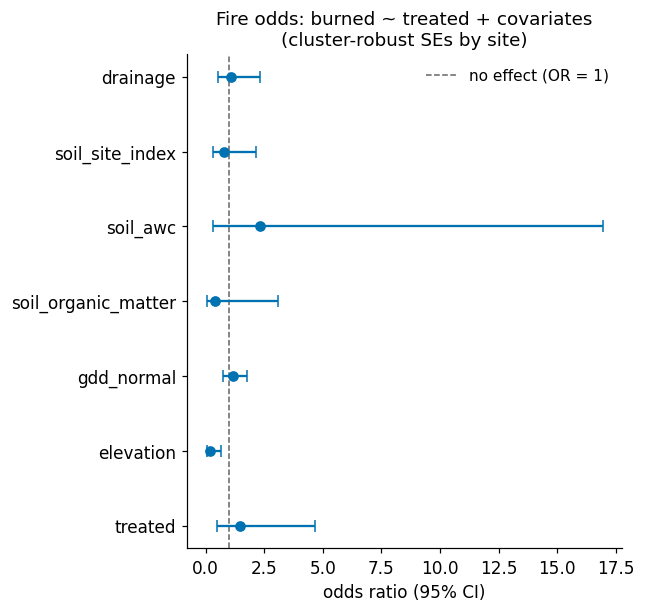

In [29]:
# Headline figure: odds ratio (95% CI) per term, saved to outputs/figures/modeling.
# treated < 1 (CI below the dashed line at OR=1) => restoration lowers fire odds.
tbl = or_table.drop(index="Intercept", errors="ignore")
ypos = np.arange(len(tbl))

fig, ax = plt.subplots(figsize=(6, 0.6 * len(tbl) + 1.5))
ax.errorbar(
    tbl["odds_ratio"],
    ypos,
    xerr=[tbl["odds_ratio"] - tbl["or_ci_low"], tbl["or_ci_high"] - tbl["odds_ratio"]],
    fmt="o",
    capsize=4,
    zorder=3,
)
ax.axvline(1.0, ls="--", color="0.4", lw=1, label="no effect (OR = 1)")
ax.set_yticks(ypos)
ax.set_yticklabels(tbl.index)
ax.set_xlabel("odds ratio (95% CI)")
ax.set_title("Fire odds: burned ~ treated + covariates\n(cluster-robust SEs by site)")
ax.legend()
fig.savefig(FIG_DIR / f"{fire_product}_odds_ratios.png", bbox_inches="tight")
print("saved", FIG_DIR / "odds_ratios.png")

plot burn rate of treated and control pixels for each site

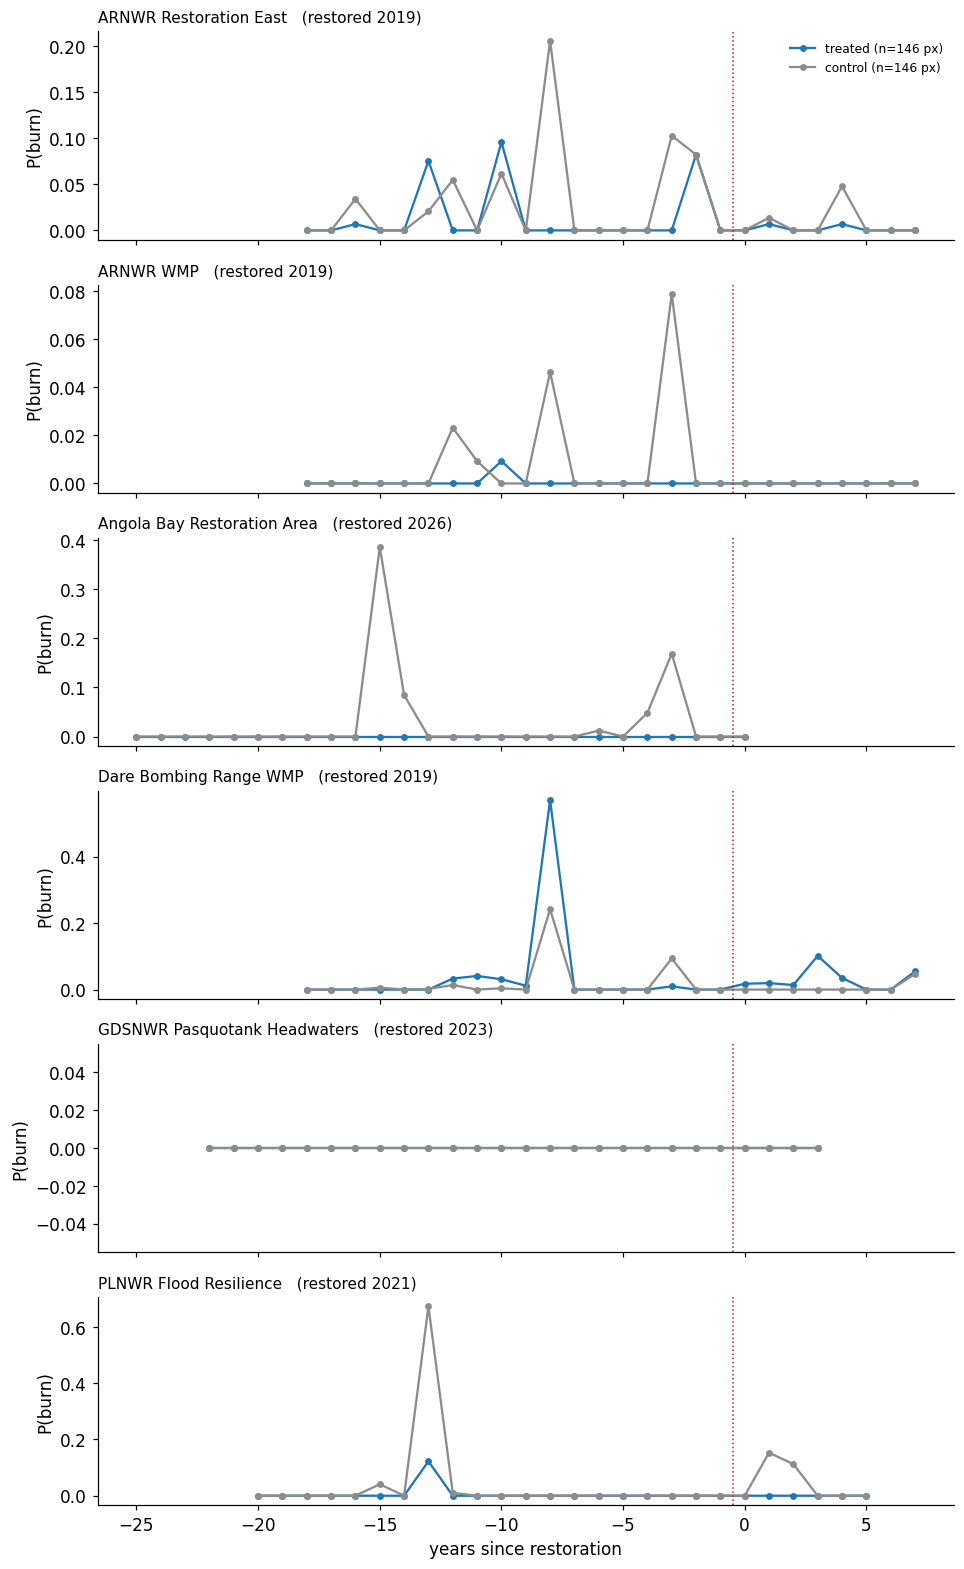

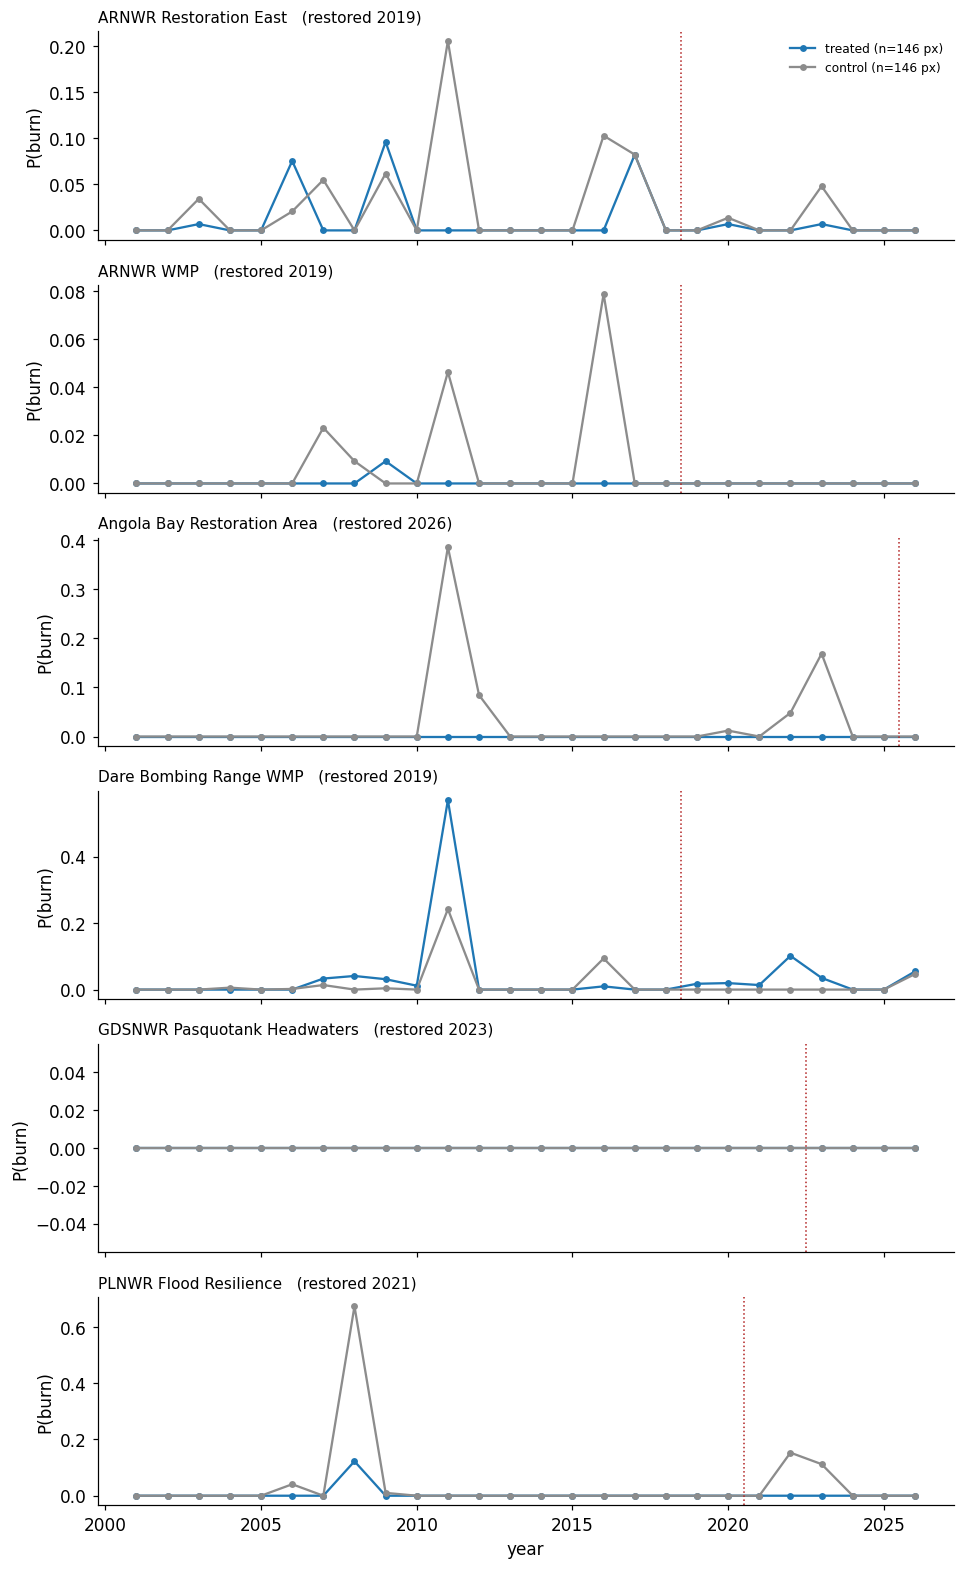

In [30]:
fig = plot_burn_rate_by_site(panel_m, x="event_time")
fig.savefig(FIG_DIR / f"{fire_product}_burn_rate_per_site_event_time.png",
            bbox_inches="tight")

# Also run it on calendar time -- that's the one that shows 2011 and 2022 as
# landscape-wide events hitting treated and control together.
fig = plot_burn_rate_by_site(panel_m, x="year")
fig.savefig(FIG_DIR / f"{fire_product}_burn_rate_per_site_calendar.png",
            bbox_inches="tight")
plt.show()

debugging